# 1. Import Ntuple

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import uproot
from tqdm.auto import tqdm
import sys
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util

training_variables = util.training_variables
columns = util.all_relevant_variables
offline_cut = util.offline_cut
lgb_tight = util.lgb_tight
lgb_loose = util.lgb_loose
lgb_comb = util.lgb_comb
lgb_all = 'ell_p>0'

In [2]:
# Load data files e
MC_4S_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run1_deimos_1/*.root:B0_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)
util.add_derived_variables([MC_4S_e,])#df_data_4S,

In [6]:
mc_4S_tight = util.apply_mva_bcs(MC_4S_e, training_variables, lgb_tight, library='lgbm',model='multiclass',
                                 perf_eval=True, truth_mode='e')


MVA cut performance  [cut: sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6]
Category                            Rate     Passing       Total
----------------------------------------------------------------
signal efficiency (B2D_tau)       0.2556       7,188      28,122
fakeD fake rate                   0.0084     132,924  15,815,120
continuum fake rate               0.0220      16,137     734,906
combinatorial fake rate           0.0430      31,812     739,879
hadronicB_secondaryL fake rate    0.0689      18,351     266,210
Event multiplicity distribution:
1    533727
2     12324
3       398
4        17
5         1
Name: count, dtype: int64
Average candidates/event before BCS: 1.024
Fraction of events with >1 candidate: 2.331%
Is best selected True

BCS performance  [bcs: vtx]
  Correct-pick rate (events with a true candidate): 0.9946
  Overall selected purity (reference only):         0.0131
  Events after BCS:                                 546,4

Is best selected True
Is best selected True
Is best selected True
Is best selected True
Is best selected True
Is best selected True


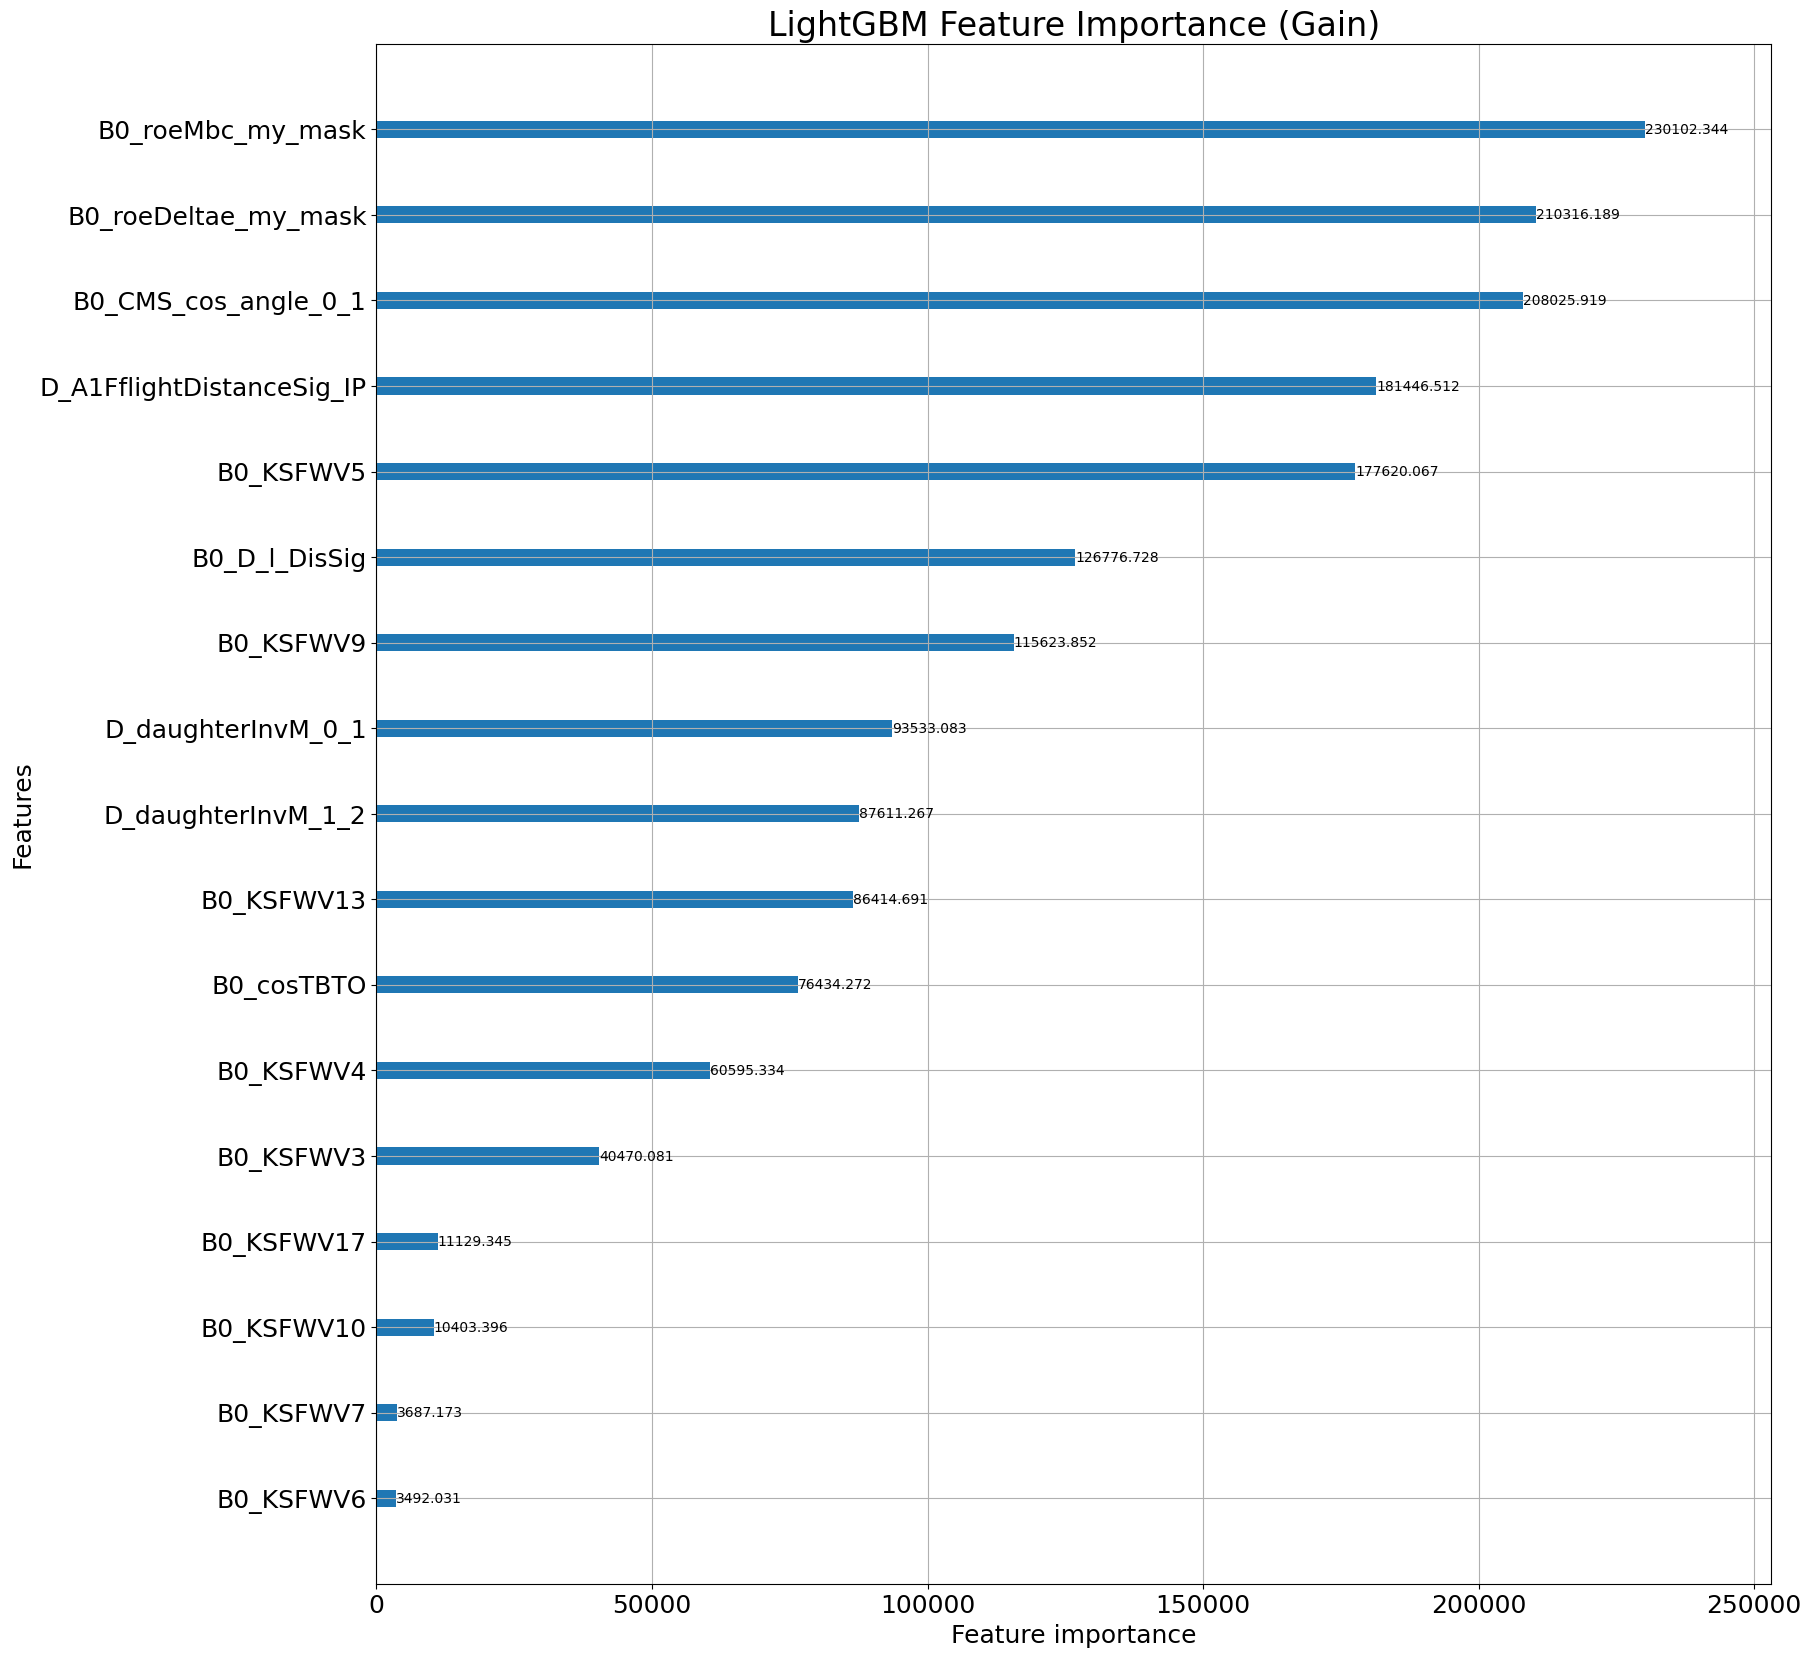

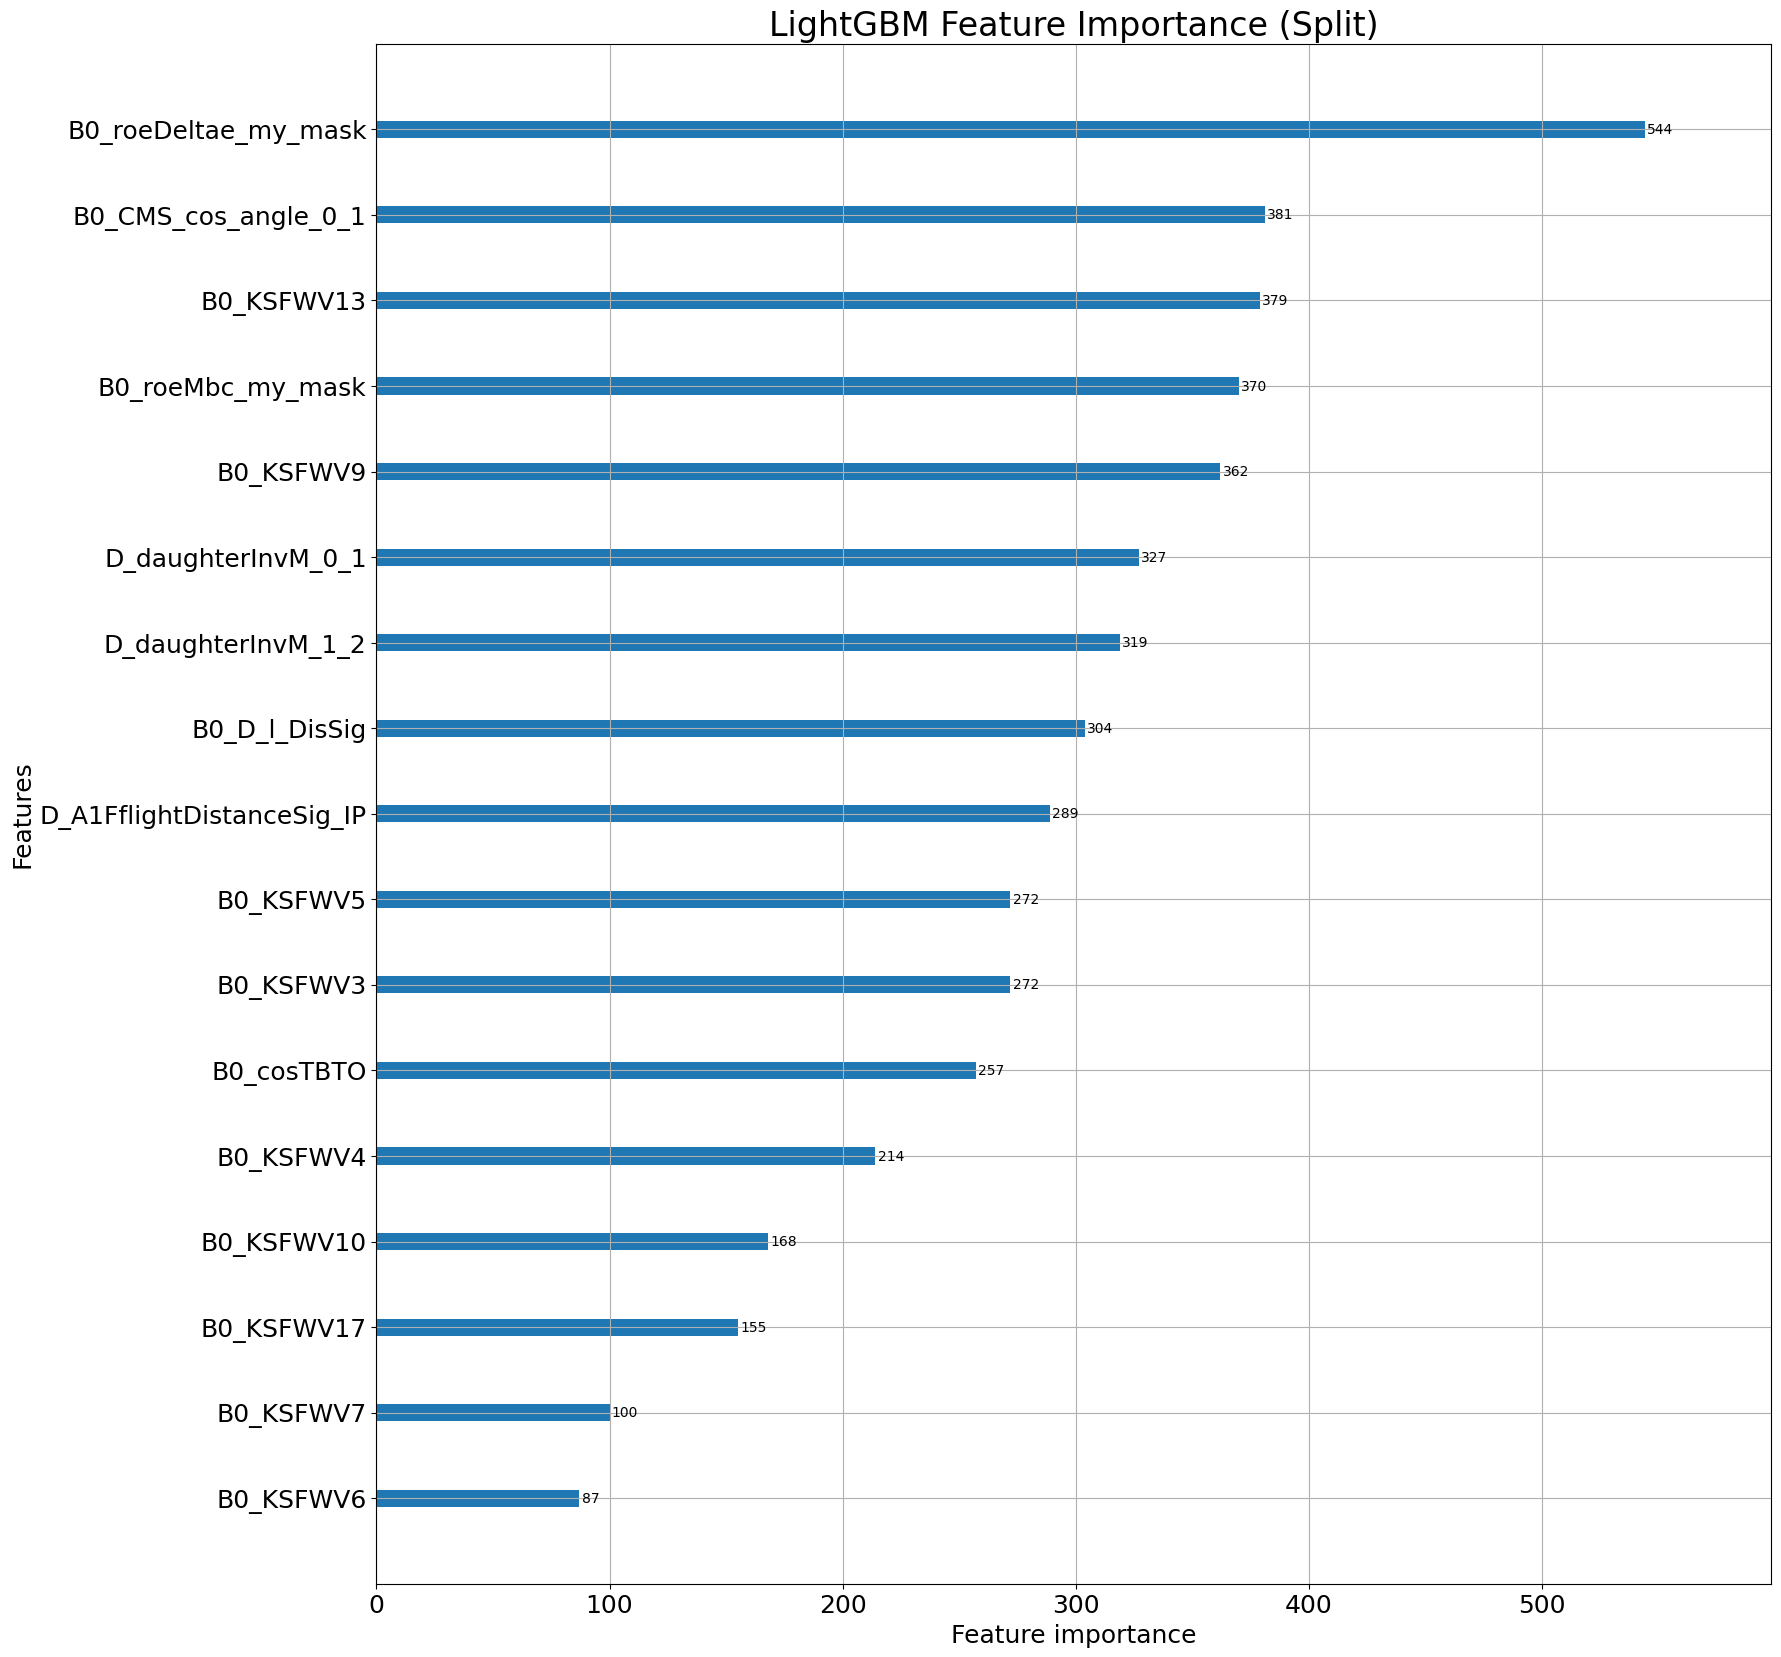

In [2]:
# 4S Run1 e mode

# Load data files e
MC_4S_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run1_deimos_1/*.root:B0_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run1_deimos_1.root:B0_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

# Load data files wrong charge e
MC_4S_wc_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run1_deimos_1/*.root:B0_wc_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_wc_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run1_deimos_1.root:B0_wc_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

for df in [MC_4S_e,data_4S_e,MC_4S_wc_e,data_4S_wc_e,]: #df_data_4S,
    # df.eval(f'cos_D_l = (D_px*ell_px + D_py*ell_py + D_pz*ell_pz)/(D_p*ell_p)', inplace=True)
    df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
    df.eval('p_D_l = D_CMS_p + ell_CMS_p', inplace=True)
    

mc_4S_loose = util.apply_mva_bcs(MC_4S_e, training_variables, lgb_loose, library='lgbm',model='multiclass',importance=True)
data_4S_loose = util.apply_mva_bcs(data_4S_e, training_variables, lgb_loose, library='lgbm',model='multiclass')

mc_4S_comb = util.apply_mva_bcs(MC_4S_e, training_variables, lgb_comb, library='lgbm',model='multiclass')
data_4S_comb = util.apply_mva_bcs(data_4S_e, training_variables, lgb_comb, library='lgbm',model='multiclass')

mc_4S_wc_loose = util.apply_mva_bcs(MC_4S_wc_e, training_variables, lgb_loose, library='lgbm',model='multiclass')
data_4S_wc_loose = util.apply_mva_bcs(data_4S_wc_e, training_variables, lgb_loose, library='lgbm',model='multiclass')

with uproot.recreate("/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root") as file:
    file["MC_e_loose"] = df_mc_4S_loose
    file["MC_e_comb"] = df_mc_4S_comb
    file["MC_wc_e_loose"] = df_mc_4S_wc_loose
    file["Data_e_loose"] = df_data_4S_loose
    file["Data_e_comb"] = df_data_4S_comb
    file["Data_wc_e_loose"] = df_data_4S_wc_loose

In [3]:
# 4S run2 e mode

# Load data files e
MC_4S_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run2_deimos_1/*.root:B0_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run2_deimos_1.root:B0_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

# Load data files wrong charge e
MC_4S_wc_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run2_deimos_1/*.root:B0_wc_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_wc_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run2_deimos_1.root:B0_wc_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

util.add_derived_variables([MC_4S_e,data_4S_e,MC_4S_wc_e,data_4S_wc_e])


df_mc_4S_loose = util.apply_mva_bcs(MC_4S_e, training_variables, lgb_loose, library='lgbm',model='multiclass')
df_data_4S_loose = util.apply_mva_bcs(data_4S_e, training_variables, lgb_loose, library='lgbm',model='multiclass')

df_mc_4S_comb = util.apply_mva_bcs(MC_4S_e, training_variables, lgb_comb, library='lgbm',model='multiclass')
df_data_4S_comb = util.apply_mva_bcs(data_4S_e, training_variables, lgb_comb, library='lgbm',model='multiclass')

df_mc_4S_wc_loose = util.apply_mva_bcs(MC_4S_wc_e, training_variables, lgb_loose, library='lgbm',model='multiclass')
df_data_4S_wc_loose = util.apply_mva_bcs(data_4S_wc_e, training_variables, lgb_loose, library='lgbm',model='multiclass')

with uproot.recreate("/home/belle/zhangboy/inclusive_R_D/Samples/4S_run2_deimos_BDT_e_3.root") as file:
    file["MC_e_loose"] = df_mc_4S_loose
    file["MC_e_comb"] = df_mc_4S_comb
    file["MC_wc_e_loose"] = df_mc_4S_wc_loose
    file["Data_e_loose"] = df_data_4S_loose
    file["Data_e_comb"] = df_data_4S_comb
    file["Data_wc_e_loose"] = df_data_4S_wc_loose

Is best selected True
Is best selected True
Is best selected True
Is best selected True
Is best selected True
Is best selected True


In [ ]:
# Load data files mu
MC_4S_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run1_deimos_1/*.root:B0_mu'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)
for df in [MC_4S_mu,]: #df_data_4S,
    # df.eval(f'cos_D_l = (D_px*ell_px + D_py*ell_py + D_pz*ell_pz)/(D_p*ell_p)', inplace=True)
    df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
    df.eval('p_D_l = D_CMS_p + ell_CMS_p', inplace=True)
mc_4S_loose = util.apply_mva_bcs(MC_4S_mu, training_variables, lgb_loose, library='lgbm',model='multiclass',
                                 perf_eval=True, truth_mode='mu')

In [4]:
# 4S Run1 mu mode

# Load data files mu
MC_4S_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run1_deimos_1/*.root:B0_mu'],
                          library="np",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run1_deimos_1.root:B0_mu'],
                          library="np",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

df_mc_4S_mu = pd.DataFrame(MC_4S_mu)
df_data_4S_mu = pd.DataFrame(data_4S_mu)

# Load data files wrong charge e
MC_4S_wc_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run1_deimos_1/*.root:B0_wc_mu'],
                          library="np",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_wc_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run1_deimos_1.root:B0_wc_mu'],
                          library="np",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

df_mc_4S_wc_mu = pd.DataFrame(MC_4S_wc_mu)
df_data_4S_wc_mu = pd.DataFrame(data_4S_wc_mu)

for df in [df_mc_4S_mu,df_data_4S_mu,df_mc_4S_wc_mu,df_data_4S_wc_mu,]: #df_data_4S,
    # df.eval(f'cos_D_l = (D_px*ell_px + D_py*ell_py + D_pz*ell_pz)/(D_p*ell_p)', inplace=True)
    df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
    df.eval('p_D_l = D_CMS_p + ell_CMS_p', inplace=True)

# lgb_loose = 'sig_prob>0.5 and fakeD_prob<0.5 and continuum_prob<0.5 and combinatorial_prob<0.5'
# lgb_comb = 'fakeD_prob<0.1 and continuum_prob<0.1 and combinatorial_prob>0.5'

df_mc_4S_loose = util.apply_mva_bcs(df_mc_4S_mu, training_variables, lgb_loose, library='lgbm',model='multiclass')
df_data_4S_loose = util.apply_mva_bcs(df_data_4S_mu, training_variables, lgb_loose, library='lgbm',model='multiclass')

df_mc_4S_comb = util.apply_mva_bcs(df_mc_4S_mu, training_variables, lgb_comb, library='lgbm',model='multiclass')
df_data_4S_comb = util.apply_mva_bcs(df_data_4S_mu, training_variables, lgb_comb, library='lgbm',model='multiclass')

df_mc_4S_wc_loose = util.apply_mva_bcs(df_mc_4S_wc_mu, training_variables, lgb_loose, library='lgbm',model='multiclass')
df_data_4S_wc_loose = util.apply_mva_bcs(df_data_4S_wc_mu, training_variables, lgb_loose, library='lgbm',model='multiclass')

with uproot.recreate("/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_mu_3.root") as file:
    file["MC_mu_loose"] = df_mc_4S_loose
    file["MC_mu_comb"] = df_mc_4S_comb
    file["MC_wc_mu_loose"] = df_mc_4S_wc_loose
    file["Data_mu_loose"] = df_data_4S_loose
    file["Data_mu_comb"] = df_data_4S_comb
    file["Data_wc_mu_loose"] = df_data_4S_wc_loose

Is best selected True
Is best selected True
Is best selected True
Is best selected True
Is best selected True
Is best selected True


In [5]:
# 4S run2 mu mode

# Load data files e
MC_4S_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run2_deimos_1/*.root:B0_mu'],
                          library="np",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run2_deimos_1.root:B0_mu'],
                          library="np",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

df_mc_4S_mu = pd.DataFrame(MC_4S_mu)
df_data_4S_mu = pd.DataFrame(data_4S_mu)

# Load data files wrong charge e
MC_4S_wc_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/4S_run2_deimos_1/*.root:B0_wc_mu'],
                          library="np",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_wc_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/Data/4S_run2_deimos_1.root:B0_wc_mu'],
                          library="np",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

df_mc_4S_wc_mu = pd.DataFrame(MC_4S_wc_mu)
df_data_4S_wc_mu = pd.DataFrame(data_4S_wc_mu)

for df in [df_mc_4S_mu,df_data_4S_mu,df_mc_4S_wc_mu,df_data_4S_wc_mu,]: #df_data_4S,
    # df.eval(f'cos_D_l = (D_px*ell_px + D_py*ell_py + D_pz*ell_pz)/(D_p*ell_p)', inplace=True)
    df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
    df.eval('p_D_l = D_CMS_p + ell_CMS_p', inplace=True)

# lgb_loose = 'sig_prob>0.5 and fakeD_prob<0.5 and continuum_prob<0.5 and combinatorial_prob<0.5'
# lgb_comb = 'fakeD_prob<0.1 and continuum_prob<0.1 and combinatorial_prob>0.5'

df_mc_4S_loose = util.apply_mva_bcs(df_mc_4S_mu, training_variables, lgb_loose, library='lgbm',model='multiclass')
df_data_4S_loose = util.apply_mva_bcs(df_data_4S_mu, training_variables, lgb_loose, library='lgbm',model='multiclass')

df_mc_4S_comb = util.apply_mva_bcs(df_mc_4S_mu, training_variables, lgb_comb, library='lgbm',model='multiclass')
df_data_4S_comb = util.apply_mva_bcs(df_data_4S_mu, training_variables, lgb_comb, library='lgbm',model='multiclass')

df_mc_4S_wc_loose = util.apply_mva_bcs(df_mc_4S_wc_mu, training_variables, lgb_loose, library='lgbm',model='multiclass')
df_data_4S_wc_loose = util.apply_mva_bcs(df_data_4S_wc_mu, training_variables, lgb_loose, library='lgbm',model='multiclass')

with uproot.recreate("/home/belle/zhangboy/inclusive_R_D/Samples/4S_run2_deimos_BDT_mu_3.root") as file:
    file["MC_mu_loose"] = df_mc_4S_loose
    file["MC_mu_comb"] = df_mc_4S_comb
    file["MC_wc_mu_loose"] = df_mc_4S_wc_loose
    file["Data_mu_loose"] = df_data_4S_loose
    file["Data_mu_comb"] = df_data_4S_comb
    file["Data_wc_mu_loose"] = df_data_4S_wc_loose

Is best selected True
Is best selected True
Is best selected True
Is best selected True
Is best selected True
Is best selected True


In [4]:
# Load data files e
signal_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/signal*_deimos_1.root:B0_e'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

signal_mu = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd/signal*_deimos_1.root:B0_mu'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)
util.add_derived_variables([signal_e, signal_mu])

df_sig_e_loose = util.apply_mva_bcs(signal_e, training_variables, lgb_loose, library='lgbm',model='multiclass',
                                   perf_eval=True, truth_mode='e')
df_sig_mu_loose = util.apply_mva_bcs(signal_mu, training_variables, lgb_loose, library='lgbm',model='multiclass',
                                    perf_eval=True, truth_mode='mu')


MVA cut performance  [cut: sig_prob>0.2 and fakeD_prob<0.15 and continuum_prob<0.5 and combinatorial_prob<0.6]
Category                            Rate     Passing       Total
----------------------------------------------------------------
signal efficiency (B2D_tau)       0.5305   1,489,545   2,807,703
fakeD fake rate                   0.1442     504,424   3,497,296
continuum fake rate                  nan           0           0
combinatorial fake rate           0.3391     248,992     734,195
hadronicB_secondaryL fake rate    0.2643       5,228      19,779
Event multiplicity distribution:
1    4095433
2     215551
3      12815
4       1218
5        129
6         18
7          3
8          1
Name: count, dtype: int64
Average candidates/event before BCS: 1.057
Fraction of events with >1 candidate: 5.312%
Is best selected True

BCS performance  [bcs: vtx]
  Correct-pick rate (events with a true candidate): 0.9881
  Overall selected purity (reference only):         0.3403
  Events afte

In [5]:
df_sig_e_tight = util.apply_mva_bcs(signal_e, training_variables, lgb_tight, library='lgbm',model='multiclass',
                                   perf_eval=True, truth_mode='e')
df_sig_mu_tight = util.apply_mva_bcs(signal_mu, training_variables, lgb_tight, library='lgbm',model='multiclass',
                                    perf_eval=True, truth_mode='mu')

samples_signal_e_tight = util.classify_mc_dict(df_sig_e_tight, 'e', template=False)

for name, df in samples_signal_e_tight.items():
    print(name, len(df))


MVA cut performance  [cut: sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6]
Category                            Rate     Passing       Total
----------------------------------------------------------------
signal efficiency (B2D_tau)       0.2488     698,478   2,807,703
fakeD fake rate                   0.0347     121,360   3,497,296
continuum fake rate                  nan           0           0
combinatorial fake rate           0.1001      73,515     734,195
hadronicB_secondaryL fake rate    0.0821       1,624      19,779
Event multiplicity distribution:
1    1729239
2      46434
3       1469
4        107
5          6
7          1
Name: count, dtype: int64
Average candidates/event before BCS: 1.028
Fraction of events with >1 candidate: 2.702%
Is best selected True

BCS performance  [bcs: vtx]
  Correct-pick rate (events with a true candidate): 0.9950
  Overall selected purity (reference only):         0.3910
  Events after BCS:                    

In [2]:
# Load data files
sigMC_e = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/MC16rd_signals.root:MC_e_loose'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

samples_sig = util.classify_mc_dict(sigMC_e, 'e', template=False)
mpl_sigMC=util.mpl(samples_sig)

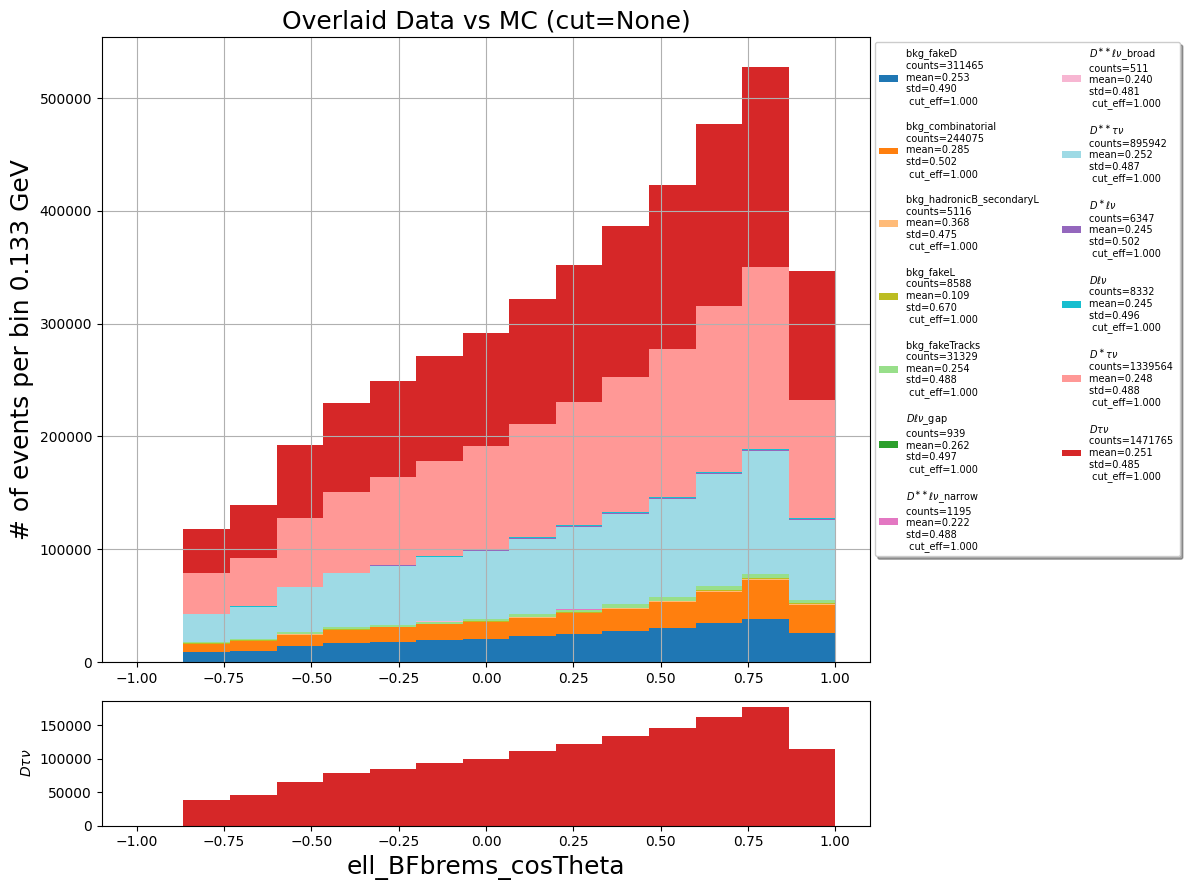

In [12]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(-1,1,16)
# weights={'all_mc':0.25 * 1.038,}
data_hist_all, mc_hist_all = mpl_sigMC.plot_data_mc_stacked(
    variable='ell_BFbrems_cosTheta',bins=b1,cut=None,mask=[],figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,text_fs=18,
    weights={},apply_eventByEvent_correction=False, eventByEvent_weight_col='total_PIDweight')

cut= 1.855<D_M<1.885 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and p_D_l<2.7 and 3<B0_recQ2BhSimple and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)


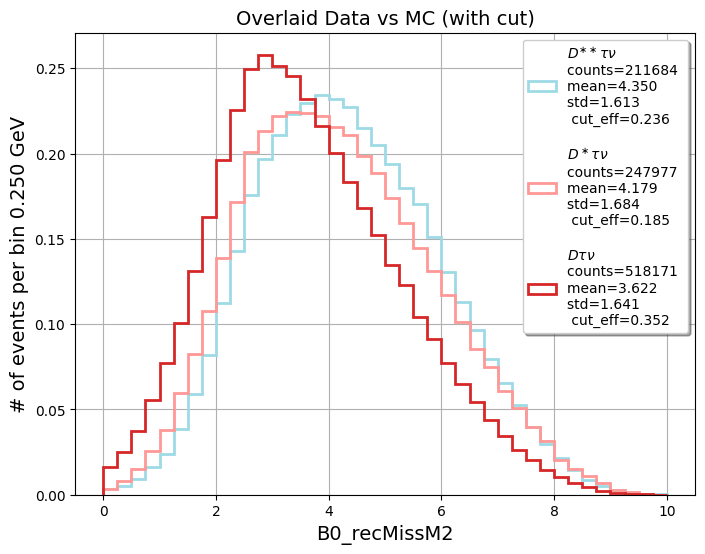

In [8]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(0,10,41)
sig_conpon = [r'$D\tau\nu$',r'$D^\ast\tau\nu$',r'$D^{\ast\ast}\tau\nu$',]
mpl_sigMC.plot_mc_1d_overlaid(variable='B0_recMissM2',bins=b1,mask=[],cut=f'1.855<D_M<1.885 and {lgb_tight} and p_D_l<2.7 and 3<B0_recQ2BhSimple and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)',
                        show_only=sig_conpon,density=True,legend_nc=1)

In [5]:
df_sig = samples_sig[r'$D\tau\nu$']

cos_col = "ell_BFbrems_cosTheta"
p_col = "ell_BFbrems_p"

region_1 = (
    df_sig[cos_col].between(-0.866, -0.104, inclusive="neither")
    & df_sig[p_col].between(3.0, 4.0, inclusive="neither")
)

region_2 = (
    df_sig[cos_col].between(-0.866, -0.682, inclusive="neither")
    & df_sig[p_col].between(2.4, 3.0, inclusive="neither")
)

region_3 = (
    df_sig[cos_col].between(0.883, 0.956, inclusive="neither")
    & df_sig[p_col].between(0.7, 1.1, inclusive="neither")
)

# Events lying inside any excluded region
excluded_mask = region_1 | region_2 | region_3

# DataFrame after removing those events
df_selected = df_sig.loc[~excluded_mask].copy()

n_before = len(df_sig)
n_removed = excluded_mask.sum()
n_after = len(df_selected)

retained_efficiency = n_after / n_before
efficiency_loss = n_removed / n_before

print(f"Events before:       {n_before}")
print(f"Events removed:      {n_removed}")
print(f"Events after:        {n_after}")
print(f"Retained efficiency: {retained_efficiency:.4%}")
print(f"Efficiency loss:     {efficiency_loss:.4%}")

for name, mask in {
    "region_1": region_1,
    "region_2": region_2,
    "region_3": region_3,
}.items():
    print(
        f"{name}: removed {mask.sum()} events "
        f"({mask.mean():.4%} of the sample)"
    )

Events before:       1471765
Events removed:      34278
Events after:        1437487
Retained efficiency: 97.6710%
Efficiency loss:     2.3290%
region_1: removed 0 events (0.0000% of the sample)
region_2: removed 0 events (0.0000% of the sample)
region_3: removed 34278 events (2.3290% of the sample)


In [7]:
# D mass signal region
samples_generic = util.classify_mc_dict(df_mc_4S_loose.query(f'1.855<D_M<1.885 and {lgb_tight}'), 'e', template=False)
# samples_sig = util.classify_mc_dict(df_mc_sig_lgb.query('1.855<D_M<1.885'), 'e', template=False)
mpl=util.mpl(samples_generic)
# mpl_sig = util.mpl(samples_sig)
for name, df in samples_generic.items():
    print(name, len(df))

bkg_fakeD 30094
bkg_fakeL 899
bkg_fakeTracks 1777
bkg_continuum 0
bkg_combinatorial 14864
bkg_hadronicB_secondaryL 10176
bkg_other_TDTl 0
$D\tau\nu$ 6475
$D^\ast\tau\nu$ 3588
$D\ell\nu$ 121246
$D^\ast\ell\nu$ 76605
$D^{\ast\ast}\tau\nu$ 744
$D^{\ast\ast}\ell\nu$_narrow 10433
$D^{\ast\ast}\ell\nu$_broad 5015
$D\ell\nu$_gap 5363
bkg_other_signal 0


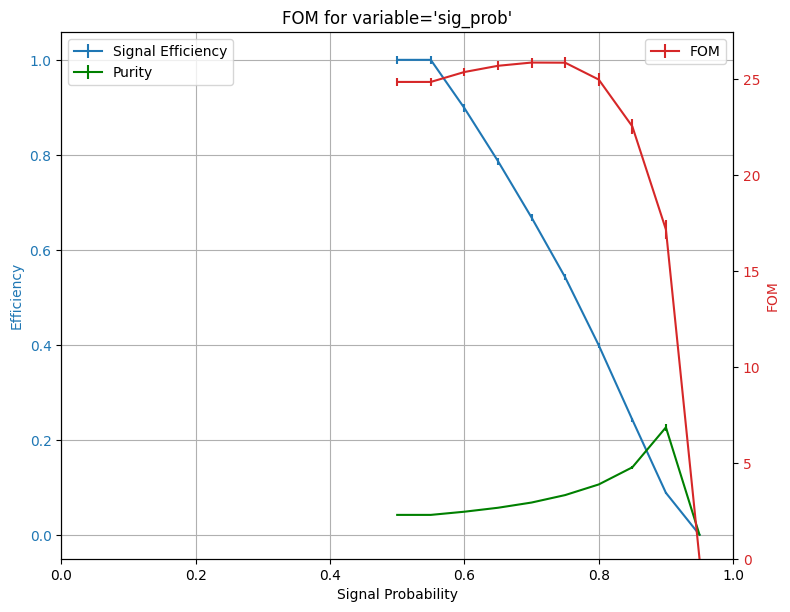

In [11]:
# lgbm
tests = np.linspace(0.5,1,11)
mpl.plot_FOM(sigModes=[r'$D\tau\nu$'],bkgModes=['bkg_fakeD','bkg_TDFl','bkg_fakeTracks',
                                                'bkg_continuum','bkg_combinatorial','bkg_singleBbkg'],
            variable='sig_prob', bins=tests)

# sig_prob>0.6 and fakeD_prob < 0.2, continumm_prob, comb_prob

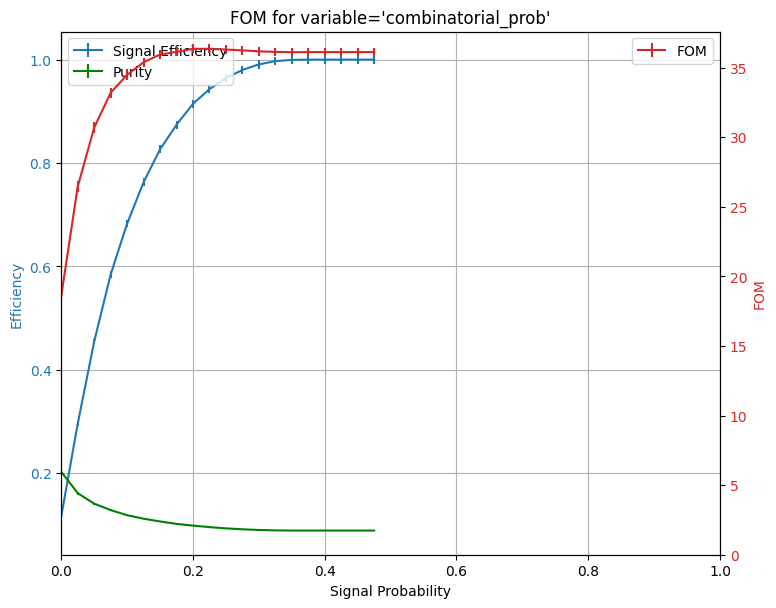

In [30]:
# lightgbm
tests = np.linspace(0,0.5,21)
mpl.plot_FOM(sigModes=[r'$D\tau\nu$'],bkgModes=['bkg_TDFl','bkg_fakeTracks',
                                                'bkg_continuum','bkg_combinatorial','bkg_singleBbkg'],
            variable='combinatorial_prob', bins=tests, cut='sig_prob>0.6 and fakeD_prob<0.1 and continuum_prob<0.1',reverse_selection=True)

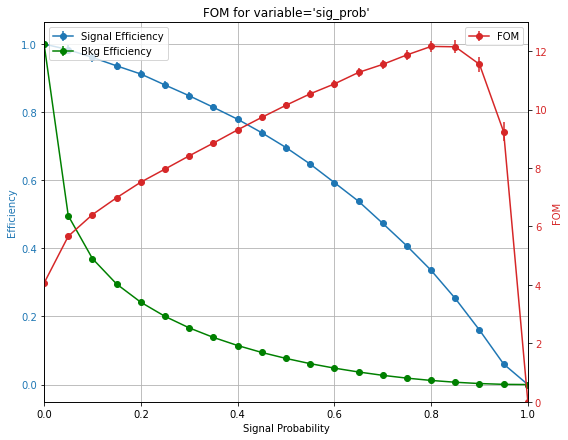

In [19]:
# lgbm
tests = np.linspace(0,1,21)
mpl.plot_FOM(sigModes=[r'$D\tau\nu$'],bkgModes=['bkg_fakeD','bkg_TDFl','bkg_fakeTracks',
                                                'bkg_continuum','bkg_combinatorial','bkg_singleBbkg'],
            variable='sig_prob', test_points=tests)

# sig_prob>0.6 and fakeD_prob < 0.2, continumm_prob, comb_prob

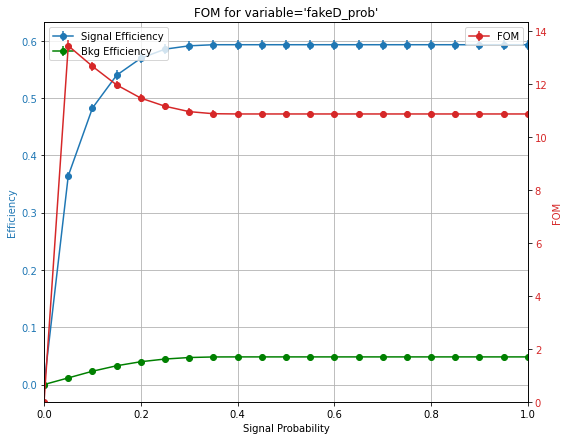

In [20]:
# lightgbm
tests = np.linspace(0,1,21)
mpl.plot_FOM(sigModes=[r'$D\tau\nu$'],bkgModes=['bkg_fakeD','bkg_TDFl','bkg_fakeTracks',
                                                'bkg_continuum','bkg_combinatorial','bkg_singleBbkg'],
            variable='fakeD_prob', test_points=tests, cut='sig_prob>0.6',reverse=True)

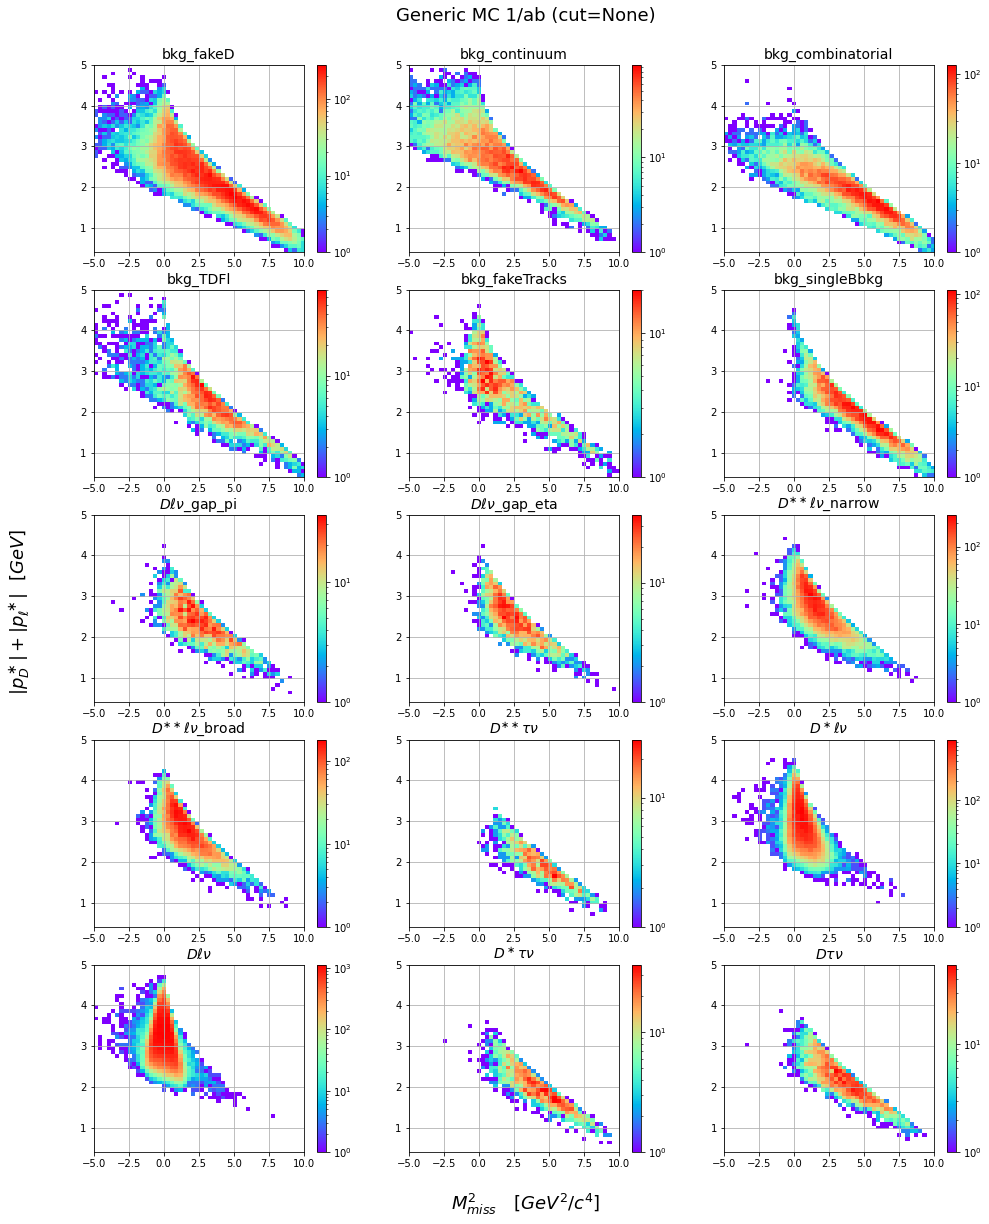

In [9]:
# Define the fitting range and number of bins, 'p_D_l'
start = 0.4
end = 5
num_bins = 50

# Create the bin edges
p_D_l_bins = np.linspace(start, end, num_bins + 1)

# Define the fitting range and number of bins, 'B0_CMS3_weMissM2'
start = -5
end = 10
num_bins = 50

# Create the bin edges
MM2_bins = np.linspace(start, end, num_bins + 1)

mpl.plot_all_2Dhist(bin_list=[MM2_bins,p_D_l_bins], mask=None,title='Generic MC 1/ab')

mpl.plot_all_2Dhist(bin_list=[MM2_bins,p_D_l_bins],cut='1.855<D_M<1.885',title='Generic MC 1/ab',mask=None)

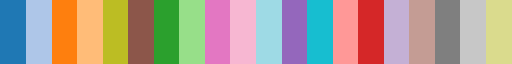

In [10]:
util.my_cmap

# Data/MC training variables @ q2 < 3 region

In [3]:
for df in [df_mc_4S_e,df_data_4S_e,]: #df_data_4S,
    # df.eval(f'cos_D_l = (D_px*ell_px + D_py*ell_py + D_pz*ell_pz)/(D_p*ell_p)', inplace=True)
    df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
    df.eval('p_D_l = D_CMS_p + ell_CMS_p', inplace=True)
lgb_all = 'ell_p>0'
df_mc_4S_all = util.apply_mva_bcs(df_mc_4S_e, training_variables, lgb_all, library='lgbm',model='multiclass')
df_data_4S_all = util.apply_mva_bcs(df_data_4S_e, training_variables, lgb_all, library='lgbm',model='multiclass')

Is best selected True
Is best selected True


In [6]:
import sysvar
import warnings

e_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/e_efficiency_MC16rd_run1_TwophotonEe.csv')
pi_e_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_e_fake_MC16rd_run1.csv')
K_e_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/K_e_fake_MC16rd_run1.csv')

tables = {(11, 11): e_eff_table,
          (11, 211): pi_e_fake,
          (11, 321): K_e_fake}
thresholds = {11: ('electronIDNN', 0.9)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('ell_BFbrems', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_all,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

k_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/k_efficiency_MC16rd_run1.csv')
pi_k_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_k_fake_MC16rd_run1.csv')

tables = {(321, 321): k_eff_table,
          (321, 211): pi_k_fake,}
thresholds = {321: ('kaonIDNN', 0.9)}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sysvar.add_weights_to_dataframe('K', # Specify your particle prefix here, e.g. "DST_D0_K"
                             df_mc_4S_all,
                             systematic='custom_PID',
                             custom_tables=tables,
                             custom_thresholds=thresholds)

# pi_eff_table = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/pi_efficiency_MC16rd_run1.csv')
# k_pi_fake = pd.read_csv('/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/MC16_pid_tables/k_pi_fake_MC16rd_run1.csv')

# tables = {(211, 211): pi_eff_table,
#           (211, 321): k_pi_fake,}
# thresholds = {211: ('pionIDNN', 0.1)}

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     sysvar.add_weights_to_dataframe('pi1', # Specify your particle prefix here, e.g. "DST_D0_K"
#                              df_mc_4S_all,
#                              systematic='custom_PID',
#                              custom_tables=tables,
#                              custom_thresholds=thresholds)
#     sysvar.add_weights_to_dataframe('pi2', # Specify your particle prefix here, e.g. "DST_D0_K"
#                              df_mc_4S_all,
#                              systematic='custom_PID',
#                              custom_tables=tables,
#                              custom_thresholds=thresholds)

df_mc_4S_all["total_PIDweight"] = df_mc_4S_all[["ell_BFbrems_Weight", "K_Weight",]].product(axis = 1)
samples_all = util.classify_mc_dict(df_mc_4S_all, 'e', template=False)
mpl_all=util.mpl(samples_all, df_data_4S_all)

Required variables: ['ell_BFbrems_cosTheta', 'ell_BFbrems_charge', 'ell_BFbrems_p', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_cosTheta', 'K_charge', 'K_p', 'K_PDG', 'K_mcPDG']


/tmp/ipykernel_2921656/1425306846.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mc_4S_all["total_PIDweight"] = df_mc_4S_all[["ell_BFbrems_Weight", "K_Weight",]].product(axis = 1)


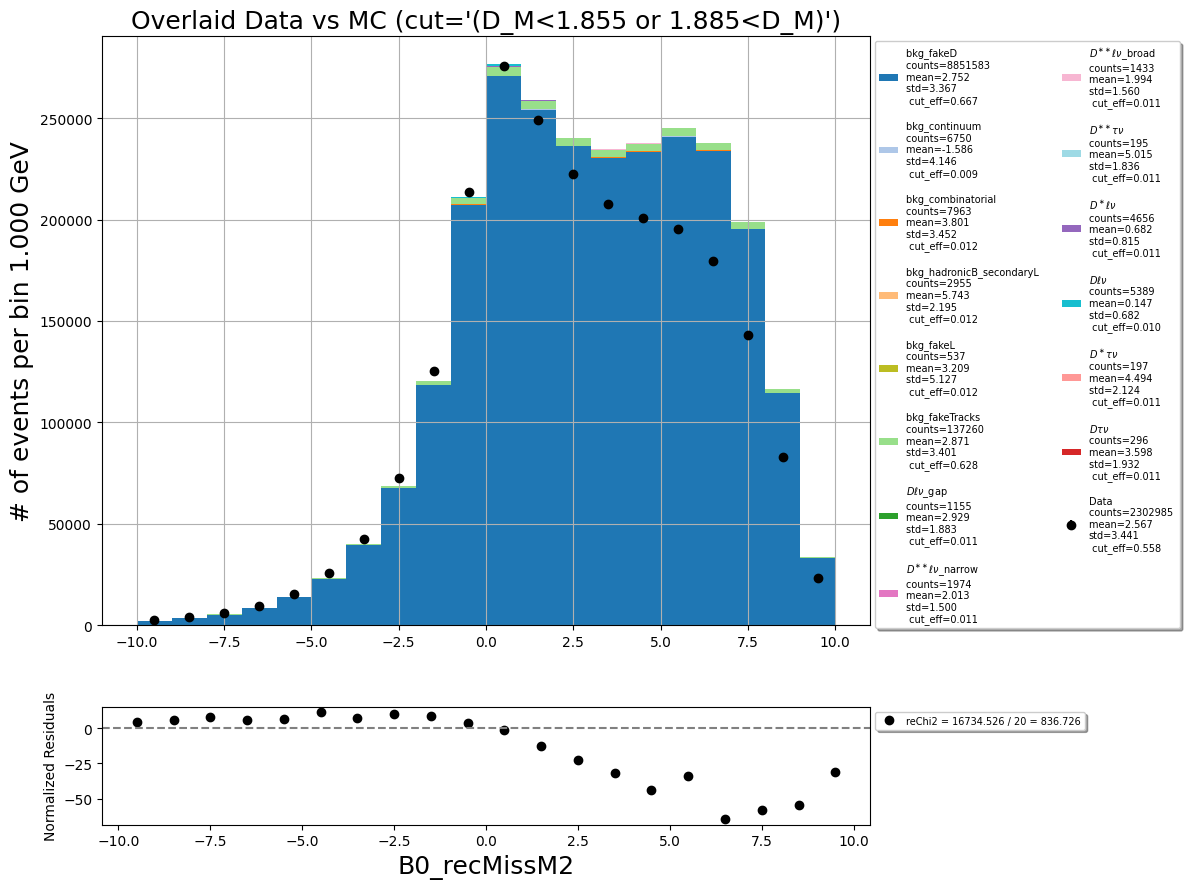

In [7]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='(D_M<1.855 or 1.885<D_M)',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

## BBbar background variables

In [ ]:
b1 = np.linspace(5,5.3,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_roeMbc_my_mask',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=False, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


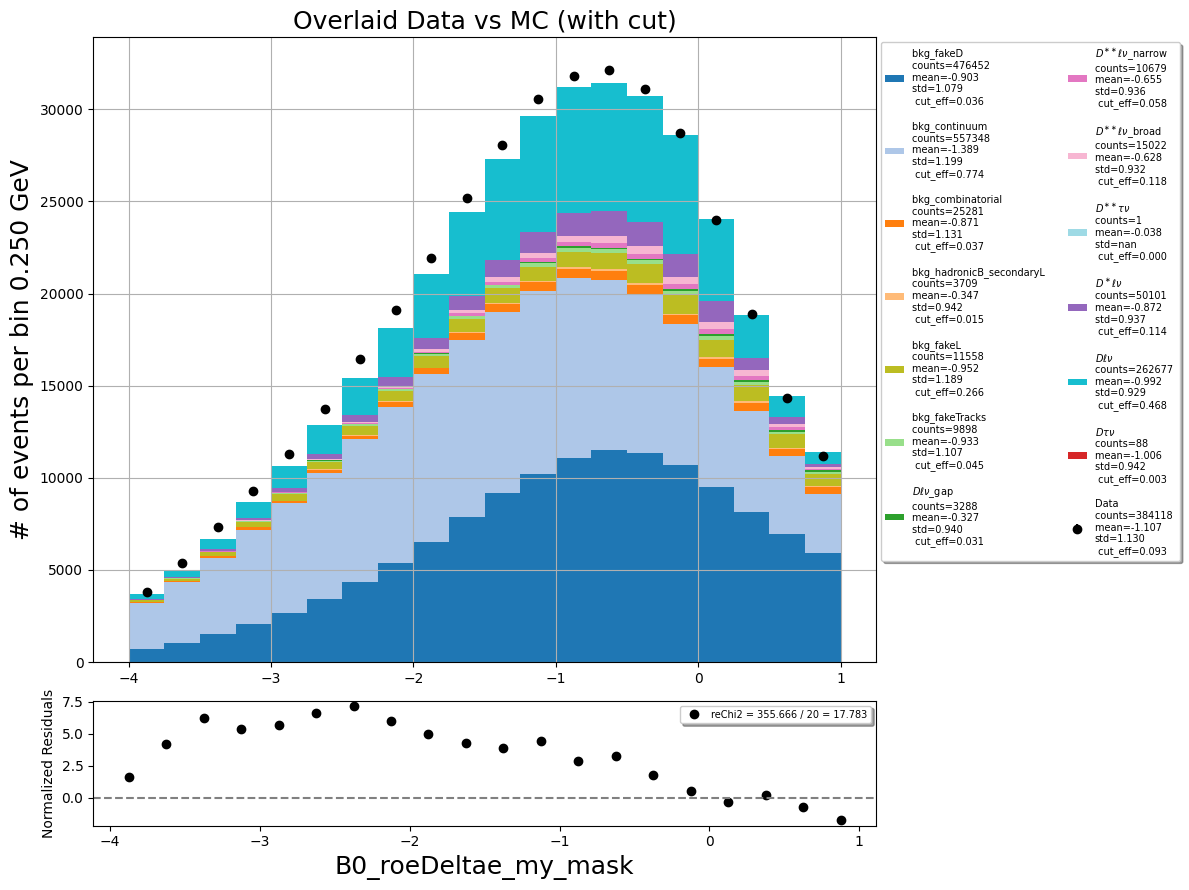

In [15]:
b1 = np.linspace(-4,1,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_roeDeltae_my_mask',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


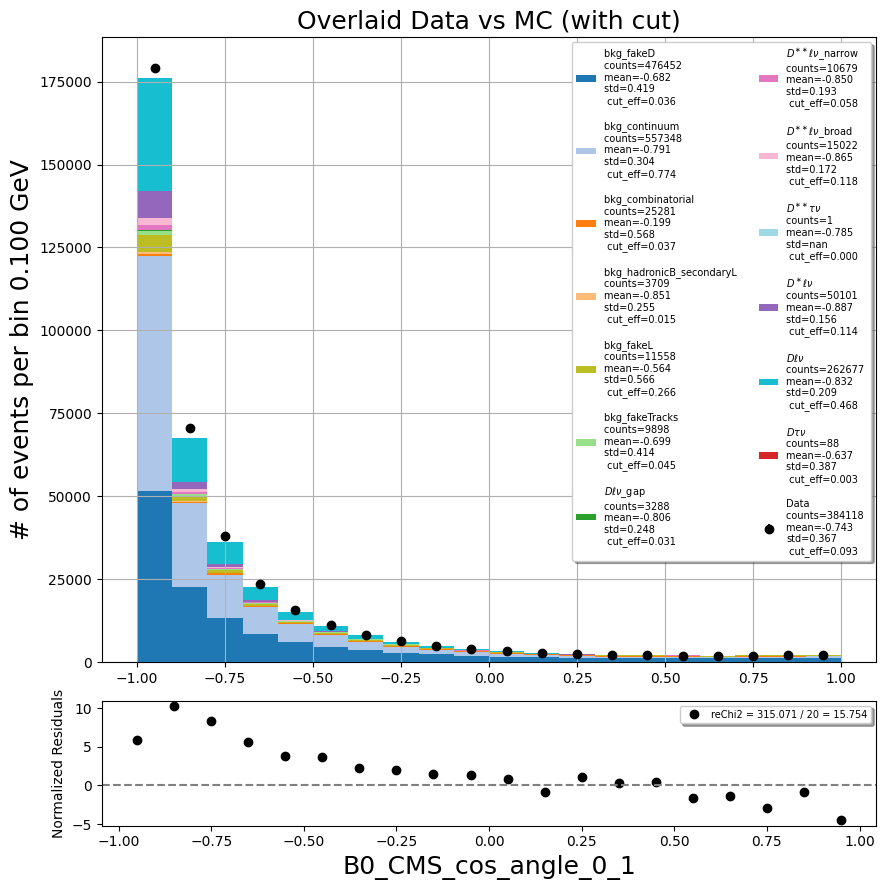

In [17]:
b1 = np.linspace(-1,1,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_CMS_cos_angle_0_1',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


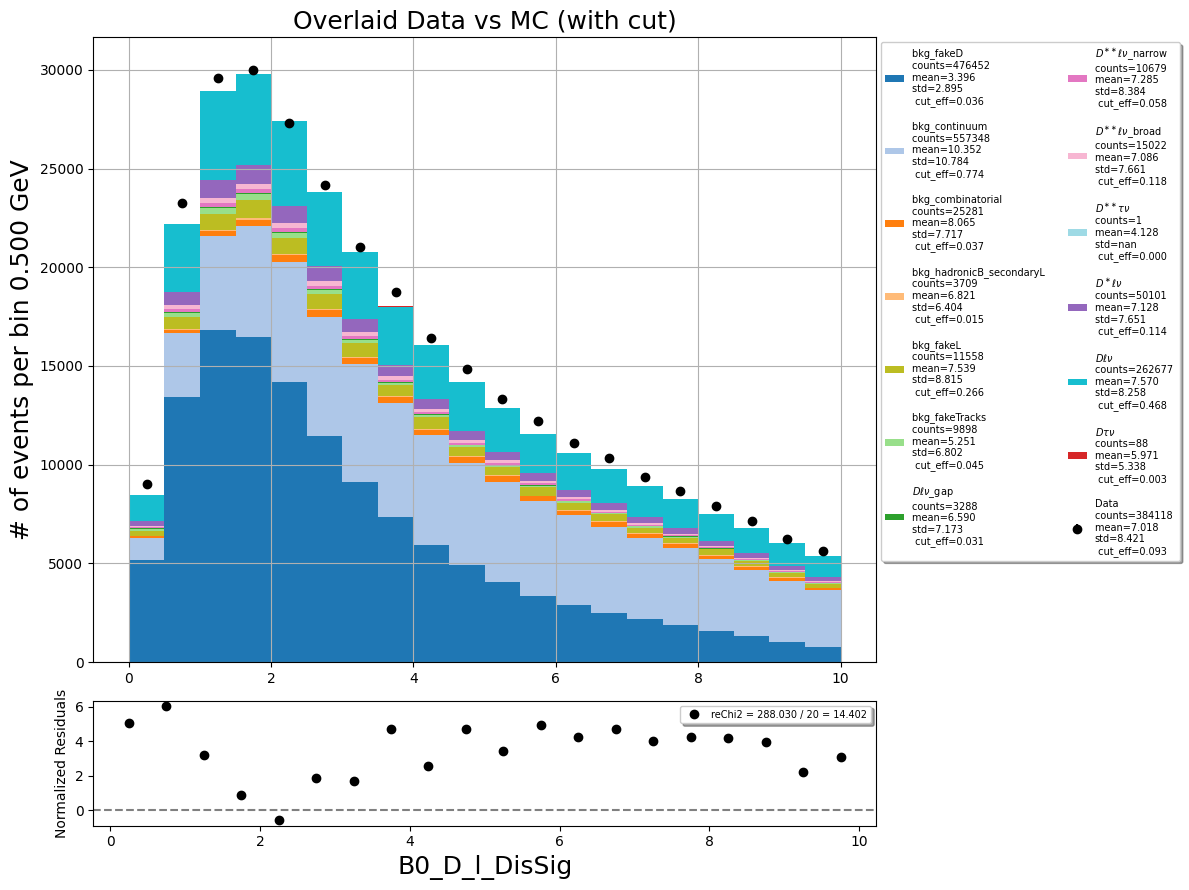

In [19]:
b1 = np.linspace(0,10,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_D_l_DisSig',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


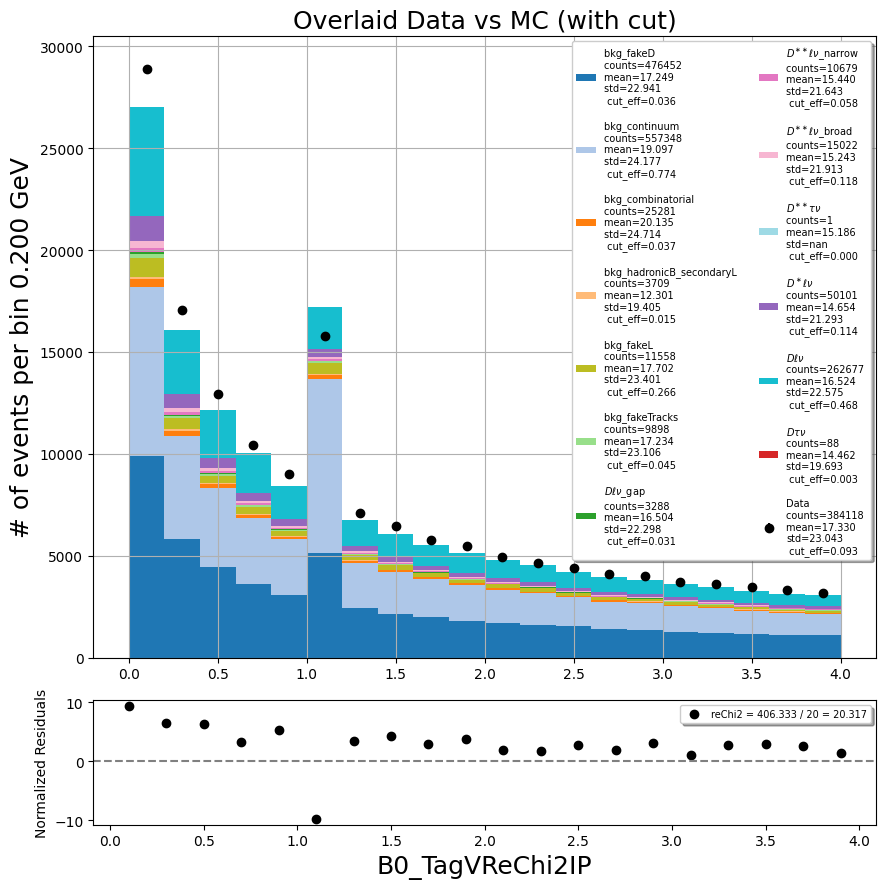

In [22]:
b1 = np.linspace(0,4,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_TagVReChi2IP',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


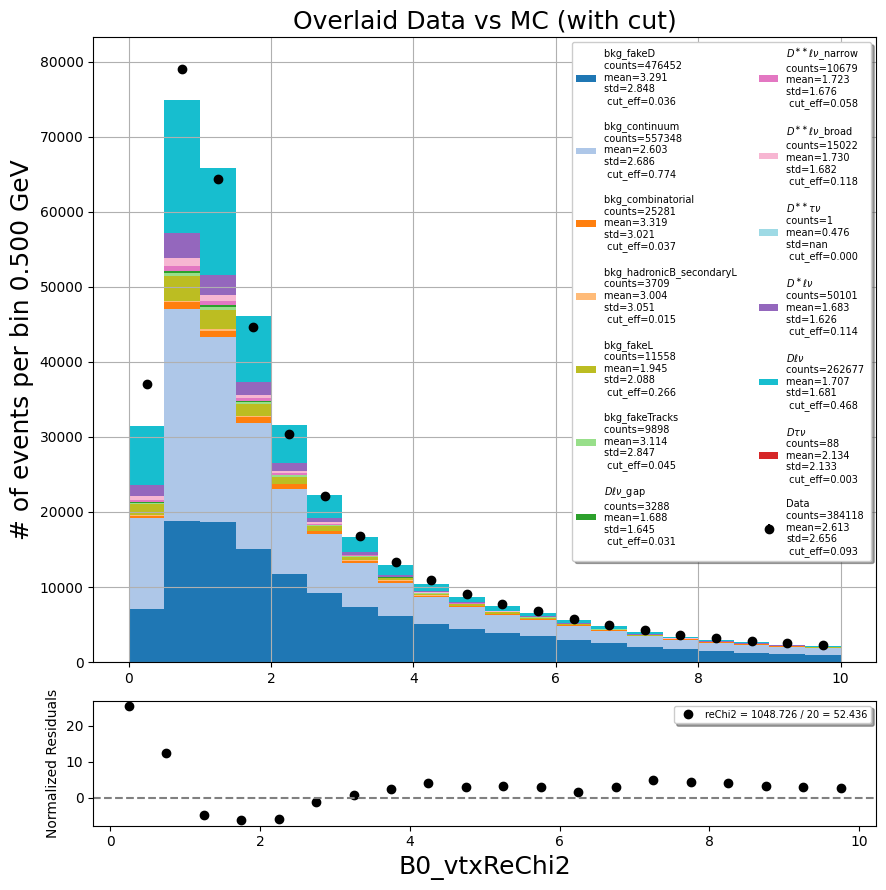

In [24]:
b1 = np.linspace(0,10,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_vtxReChi2',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

## Fake D background variables

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


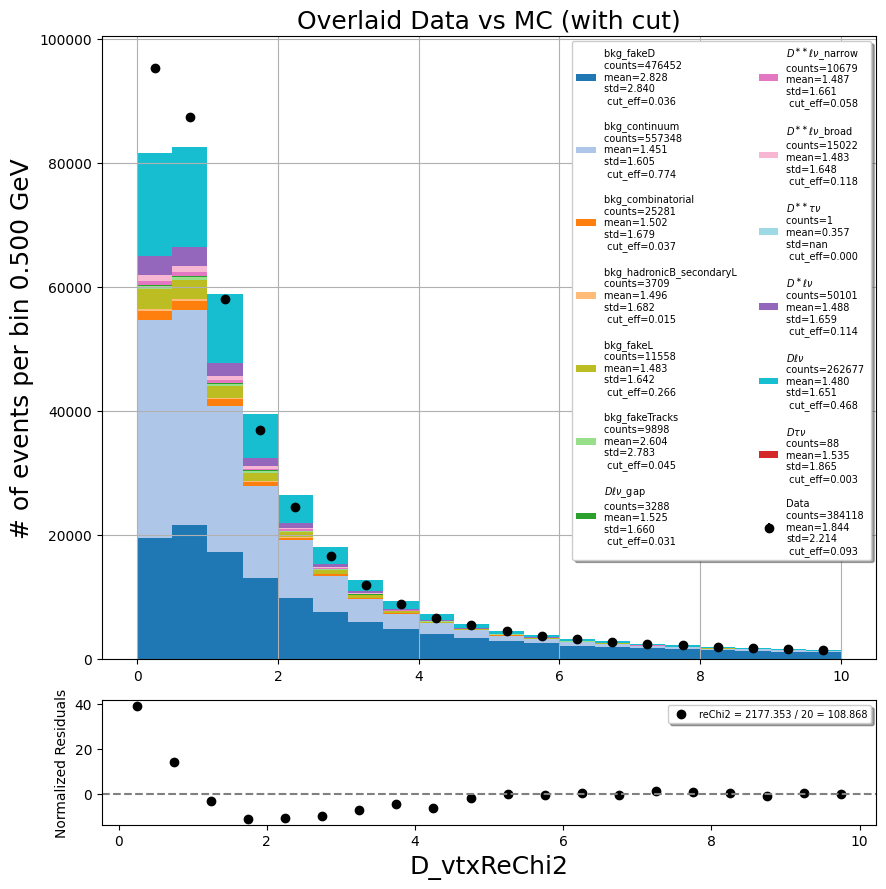

In [25]:
b1 = np.linspace(0,10,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='D_vtxReChi2',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


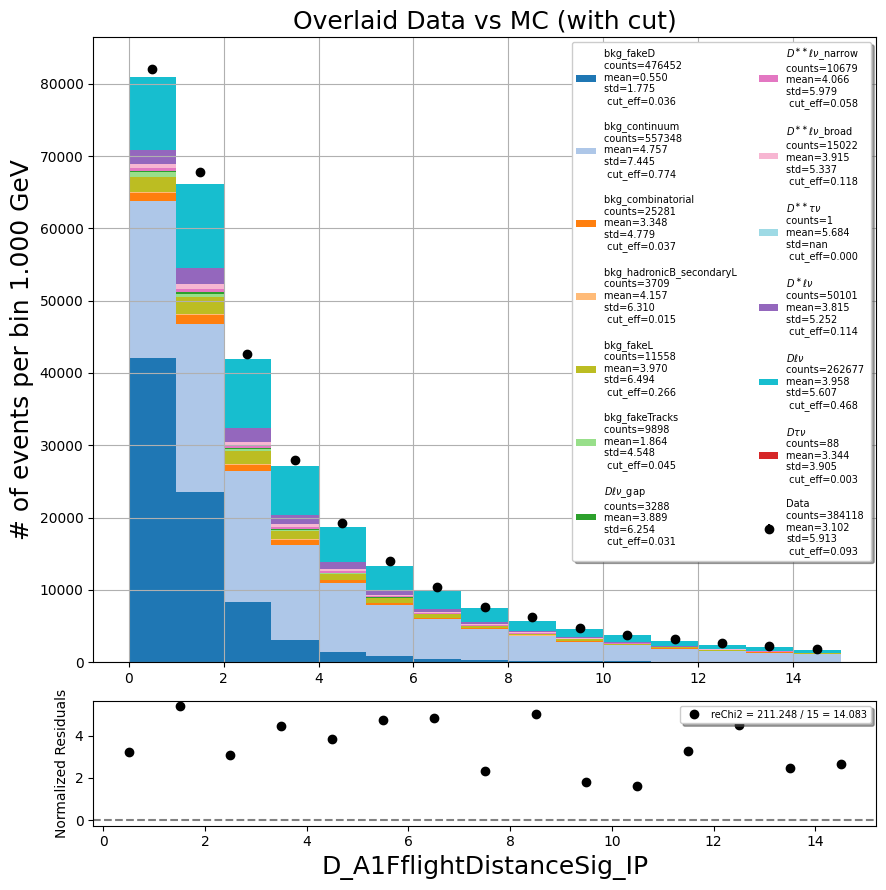

In [28]:
b1 = np.linspace(0,15,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='D_A1FflightDistanceSig_IP',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


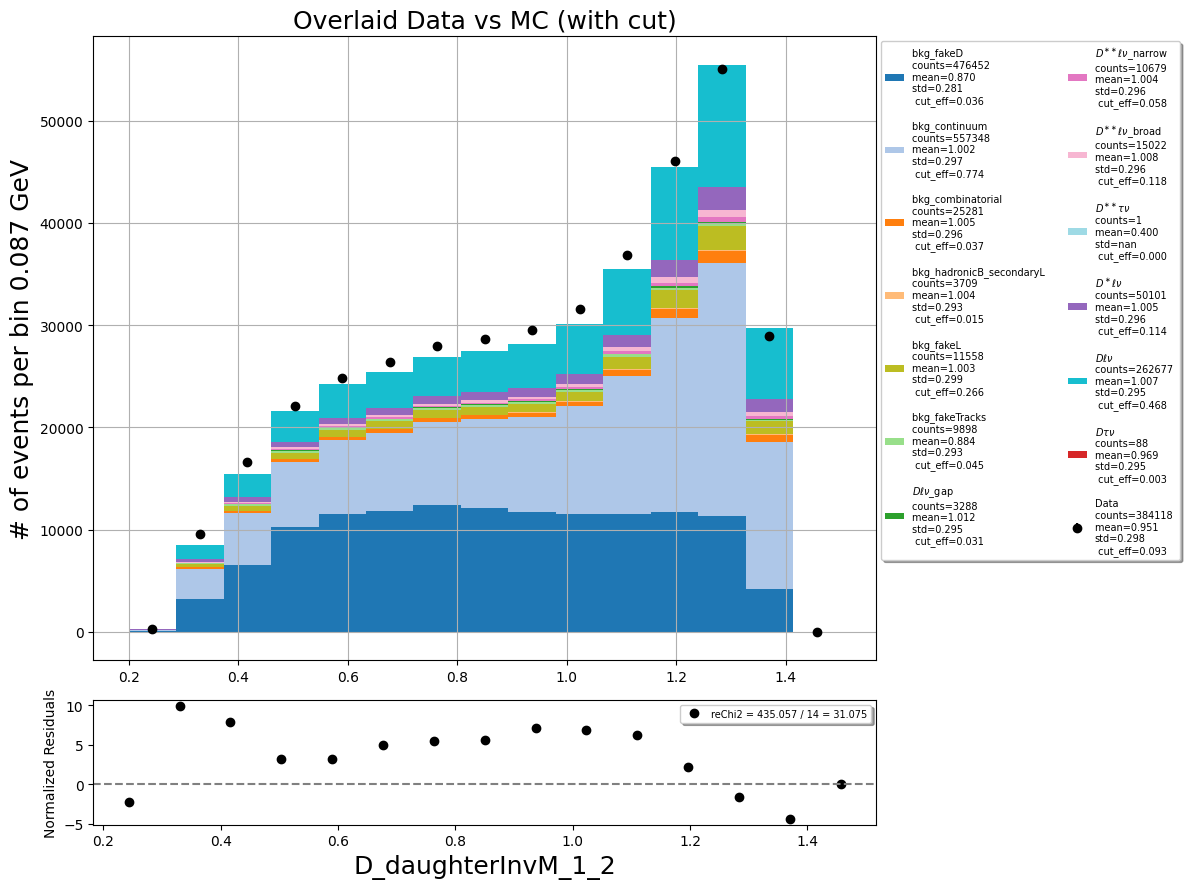

In [31]:
b1 = np.linspace(0.2,1.5,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='D_daughterInvM_1_2',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


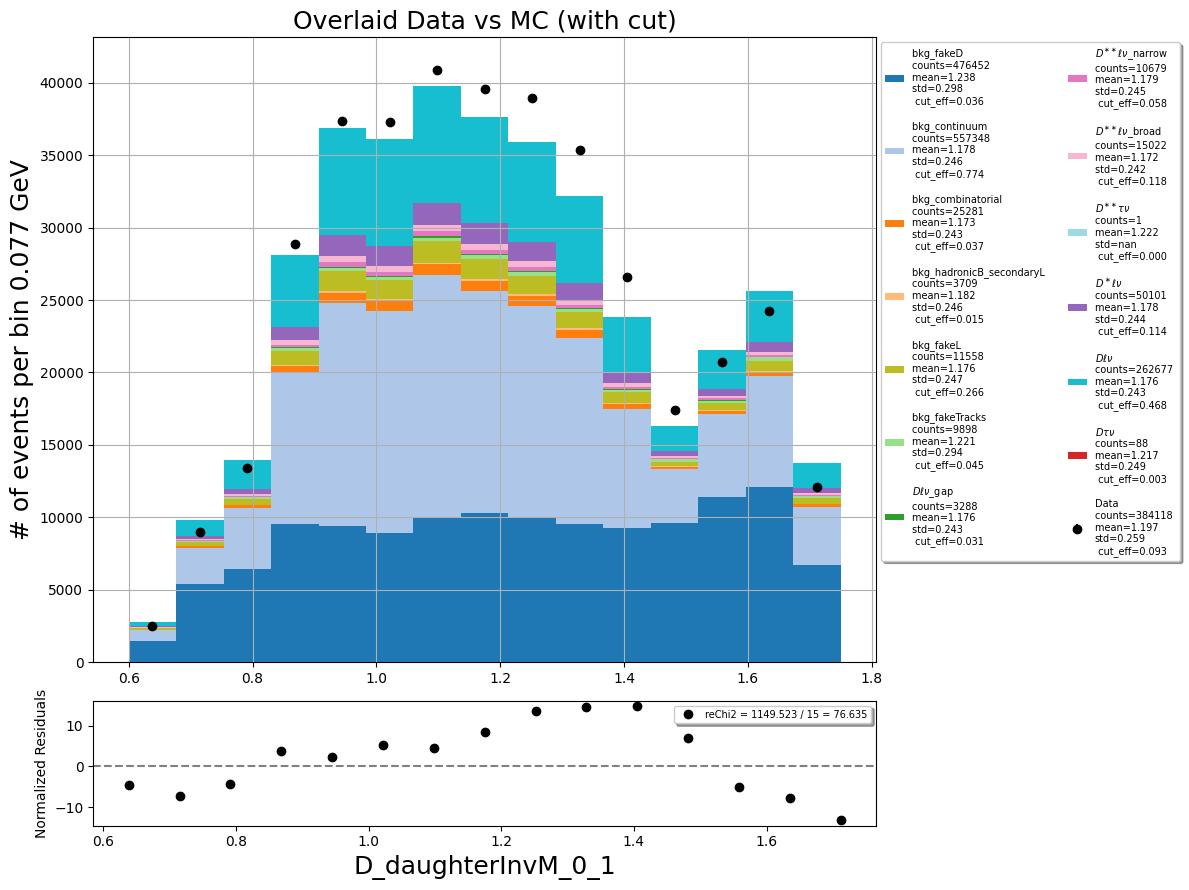

In [34]:
b1 = np.linspace(0.6,1.75,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='D_daughterInvM_0_1',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

## Continuum background variables

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


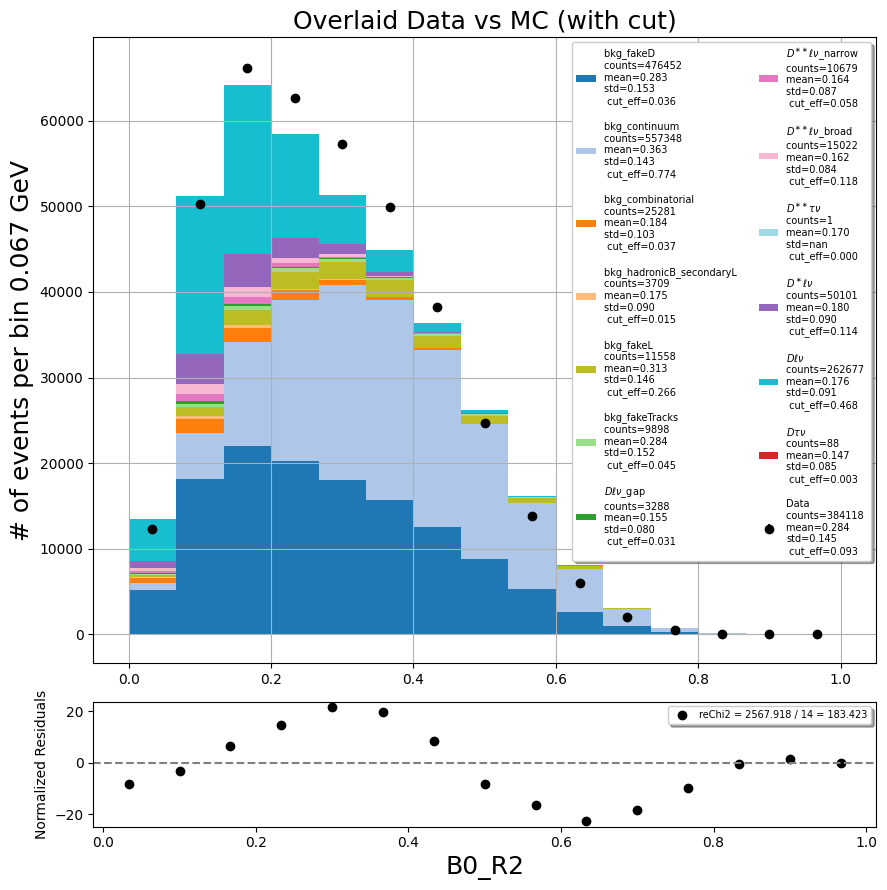

In [40]:
b1 = np.linspace(0,1,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_R2',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


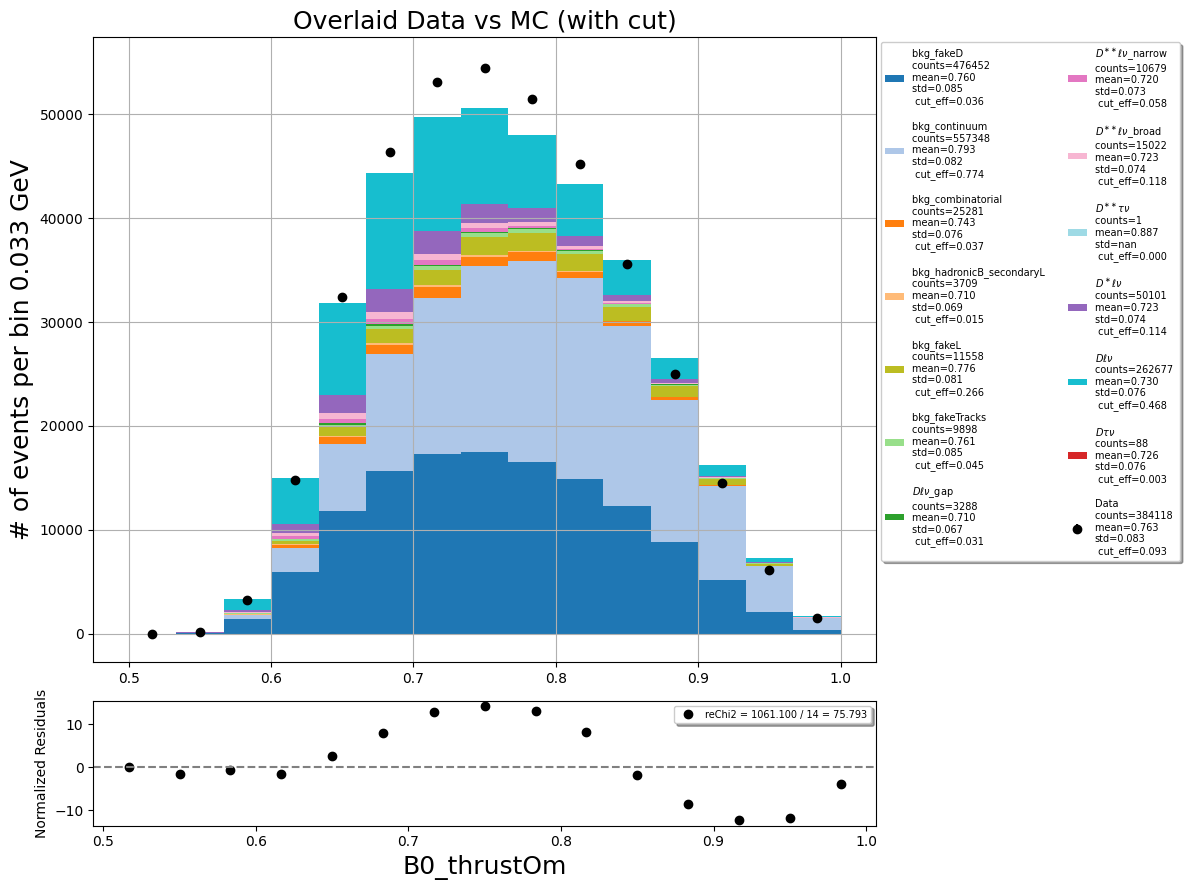

In [43]:
b1 = np.linspace(0.5,1,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_thrustOm',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


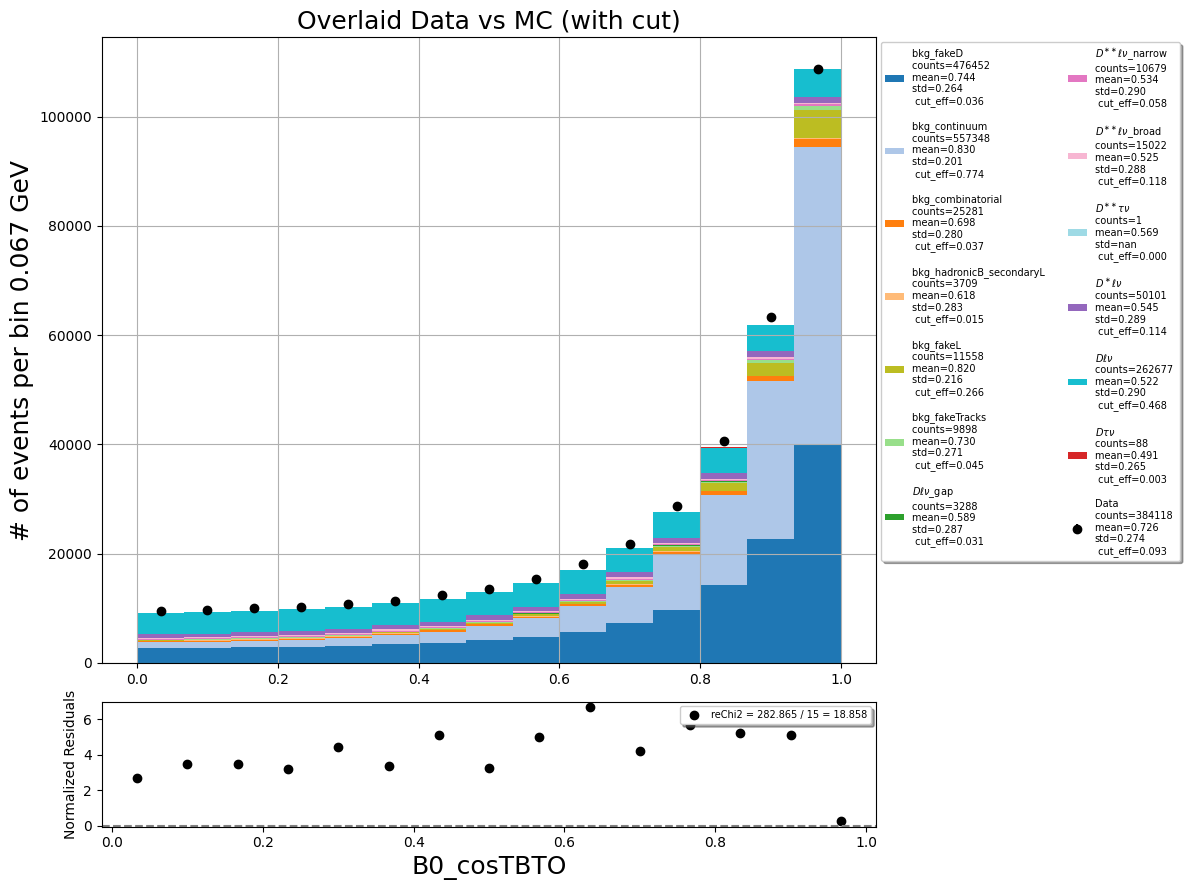

In [47]:
b1 = np.linspace(0,1,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_cosTBTO',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


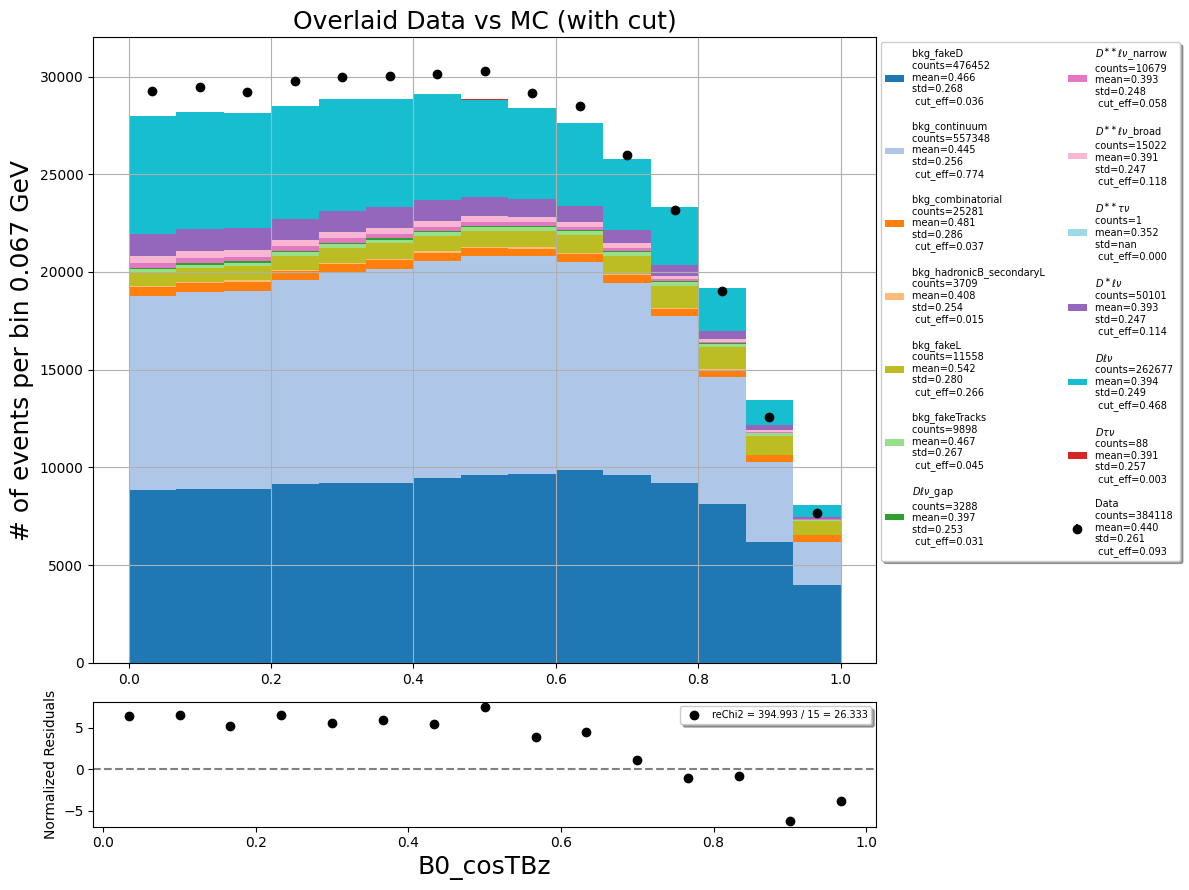

In [50]:
b1 = np.linspace(0,1,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_cosTBz',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


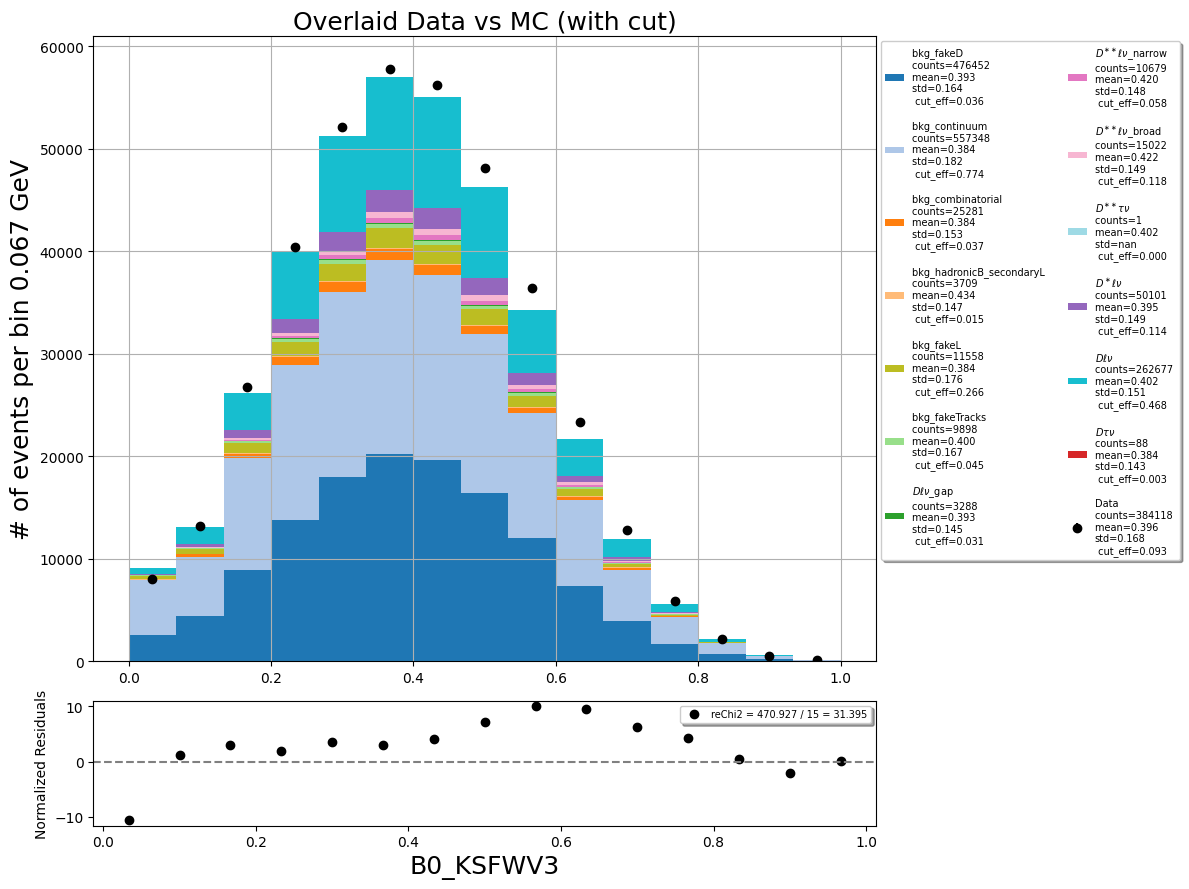

In [54]:
b1 = np.linspace(0,1,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV3',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


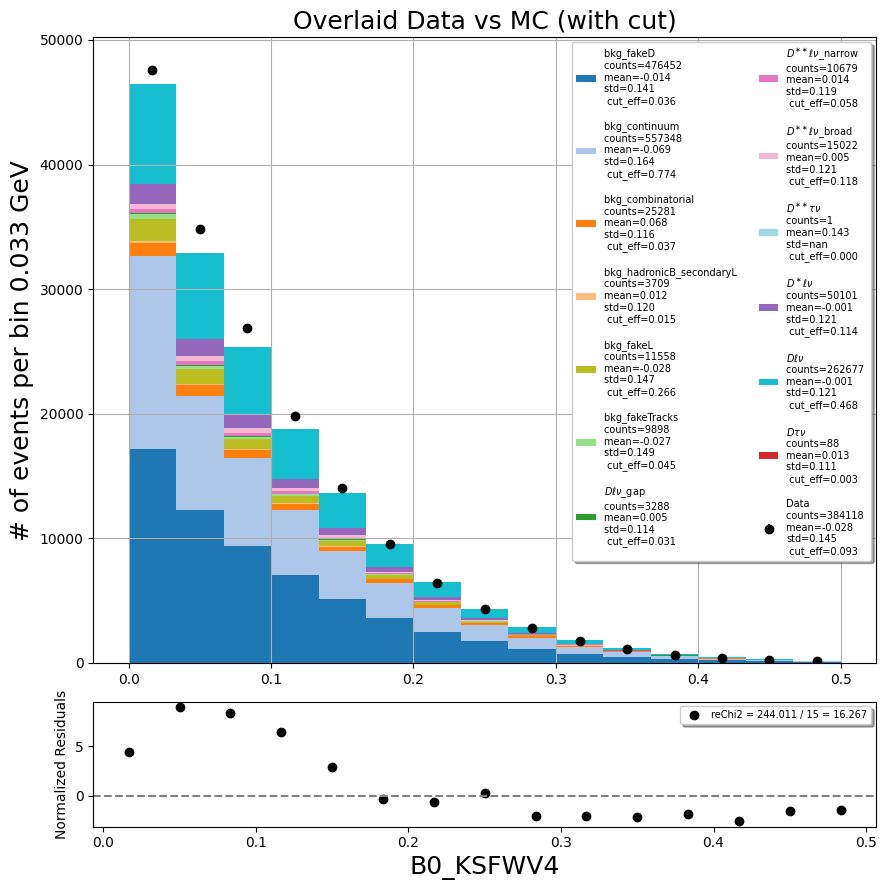

In [56]:
b1 = np.linspace(0,0.5,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV4',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


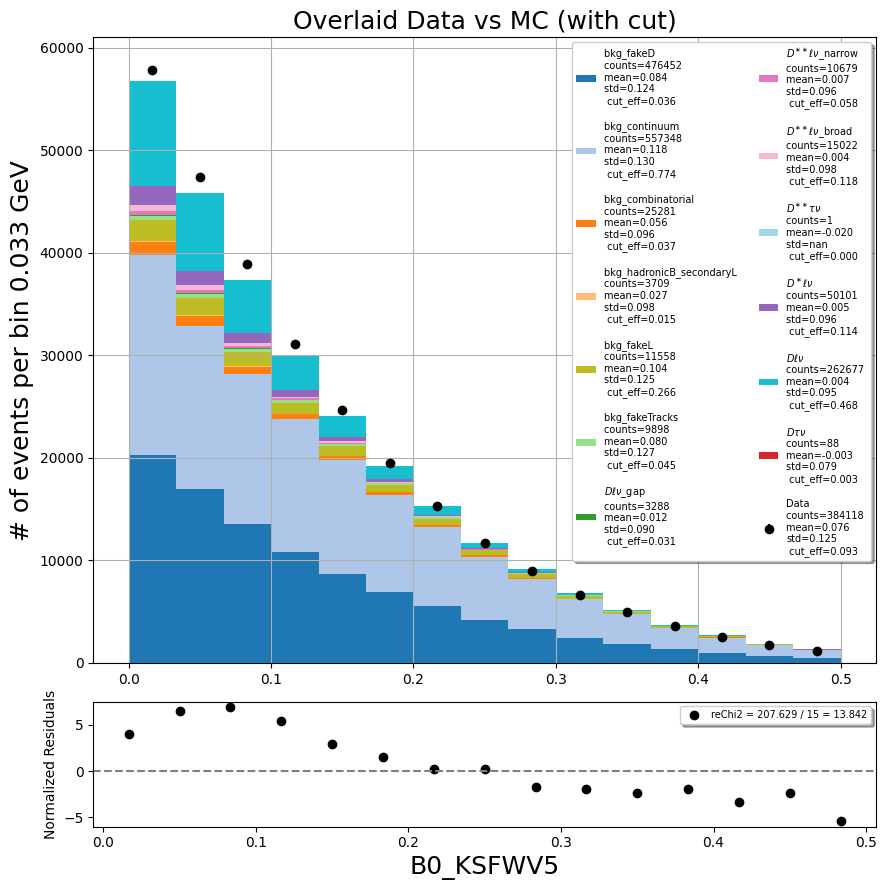

In [57]:
b1 = np.linspace(0,0.5,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV5',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


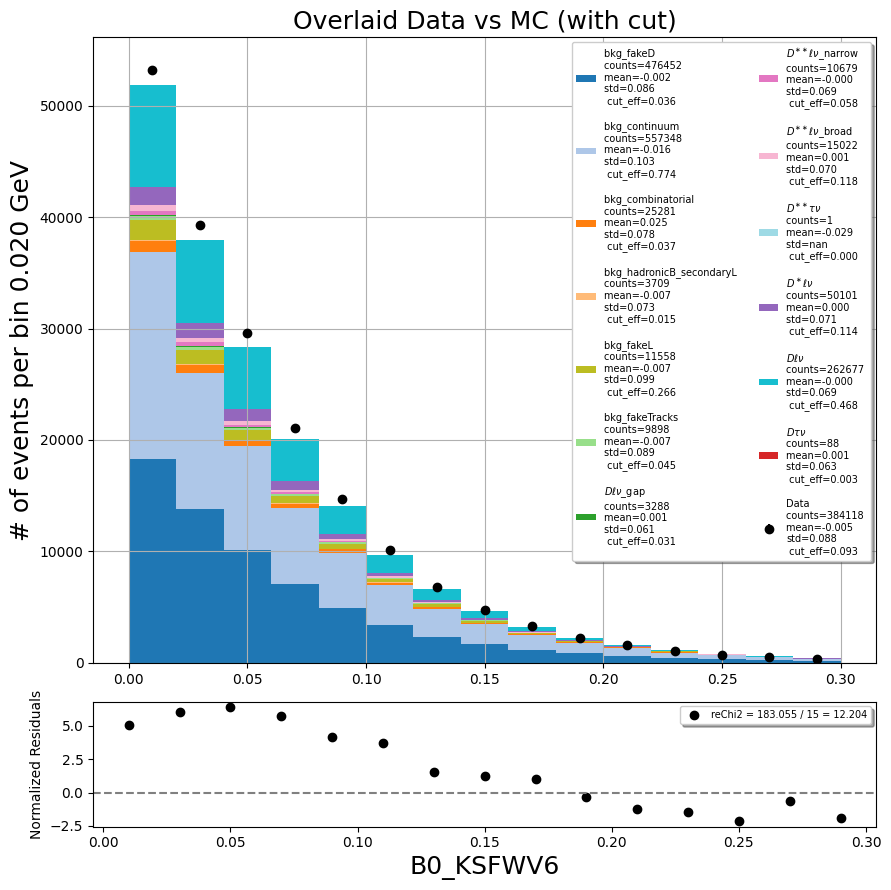

In [60]:
b1 = np.linspace(0,0.3,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV6',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


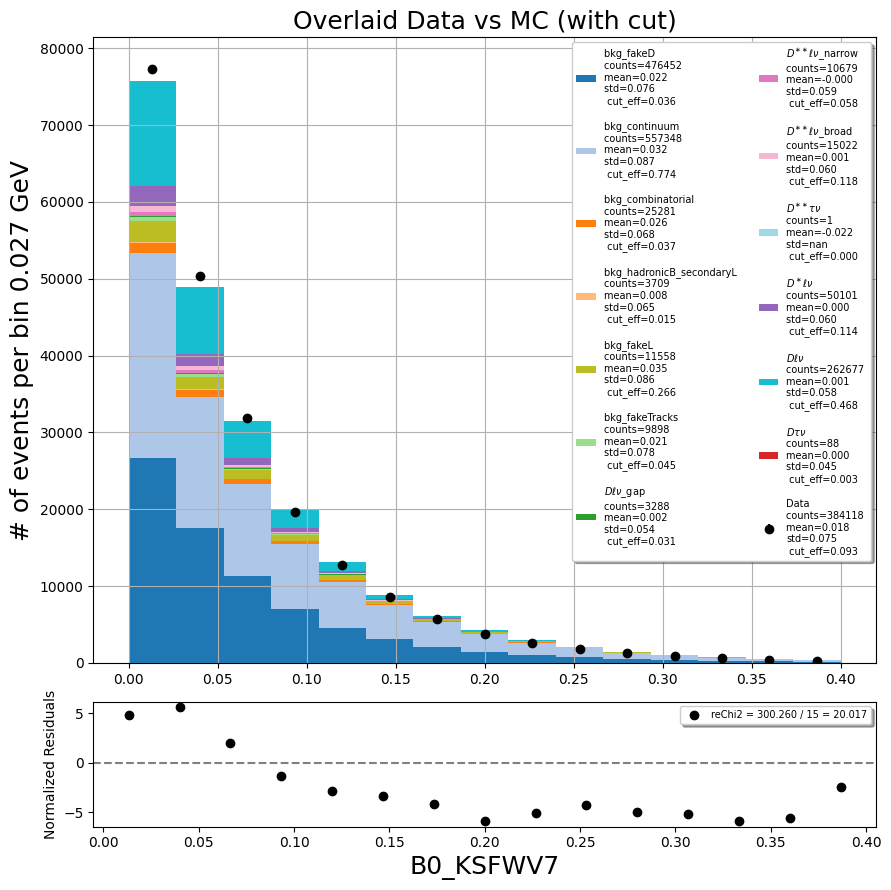

In [61]:
b1 = np.linspace(0,0.4,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV7',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


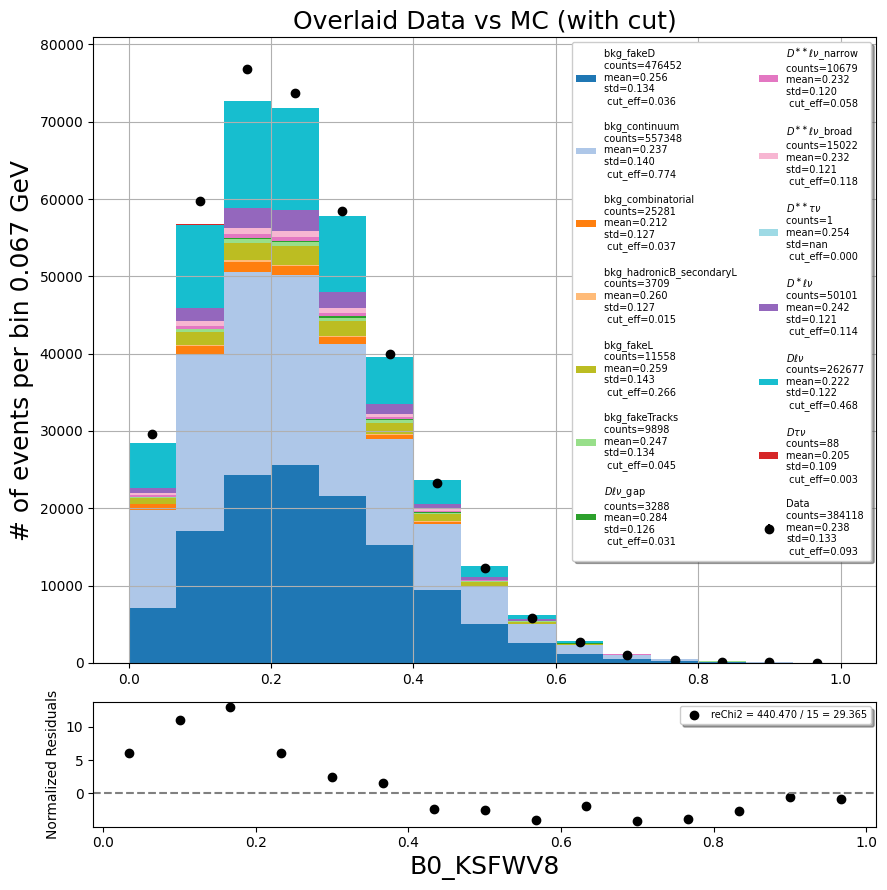

In [63]:
b1 = np.linspace(0,1,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV8',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


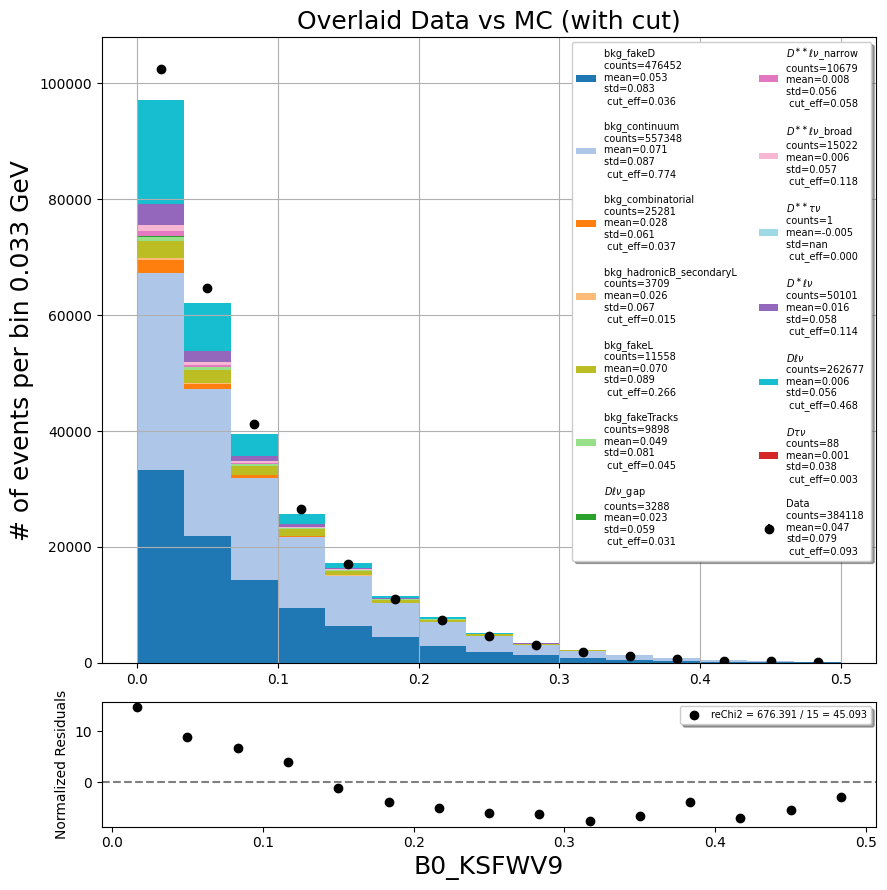

In [64]:
b1 = np.linspace(0,0.5,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV9',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


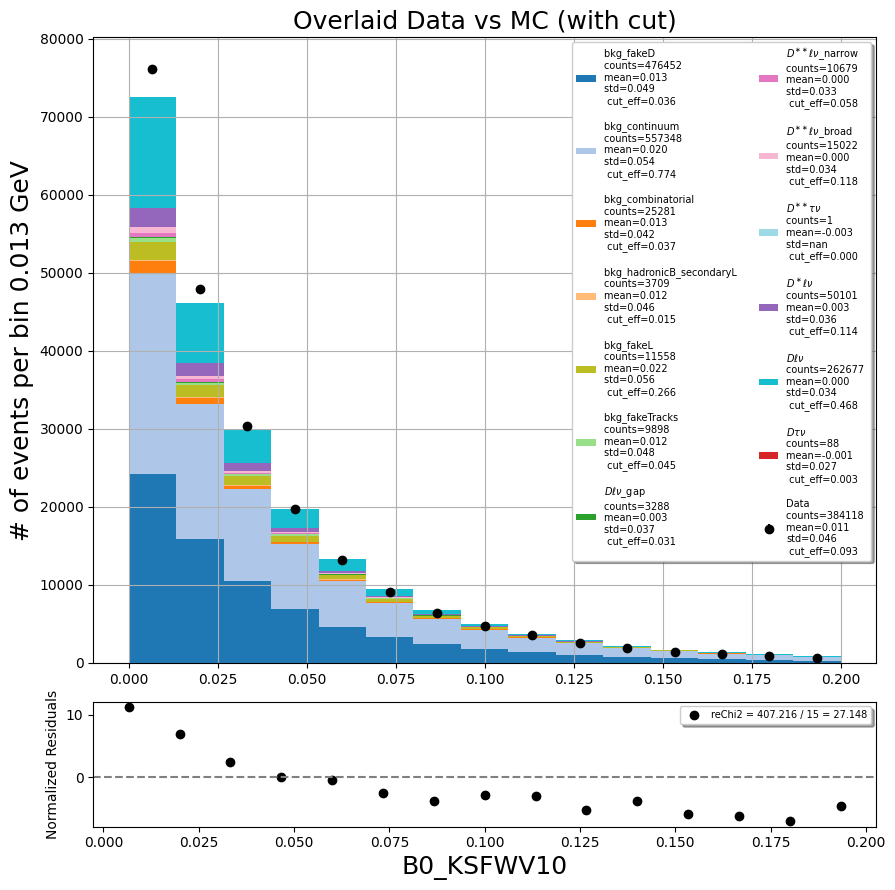

In [67]:
b1 = np.linspace(0,0.2,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV10',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


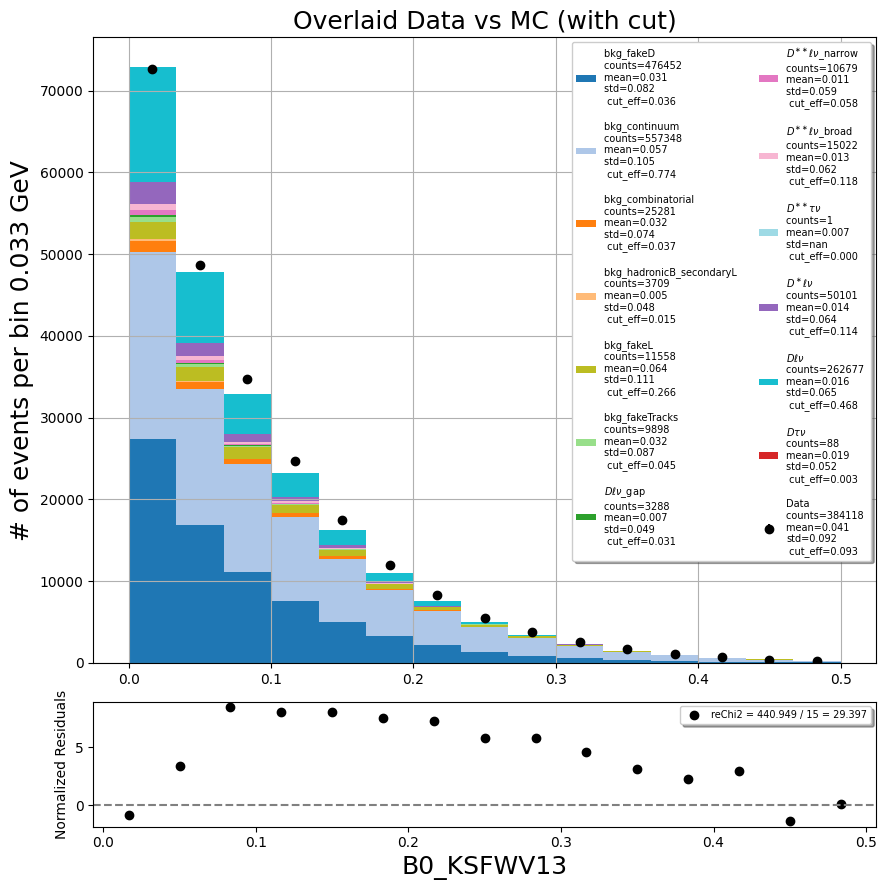

In [68]:
b1 = np.linspace(0,0.5,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV13',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


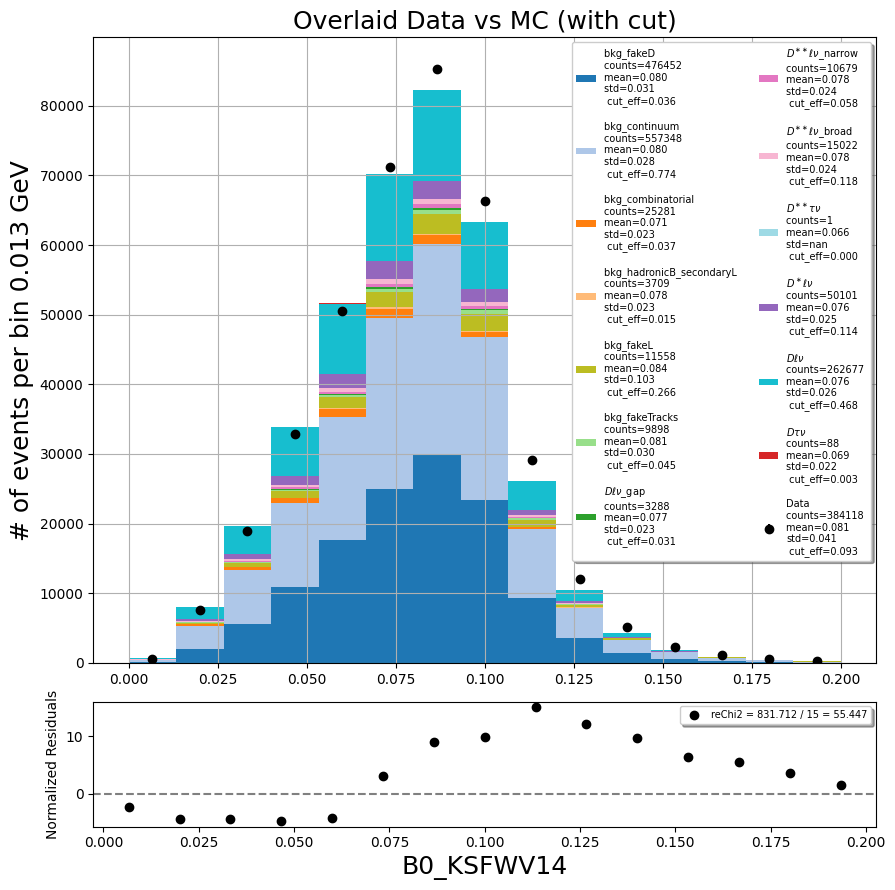

In [70]:
b1 = np.linspace(0,0.2,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV14',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


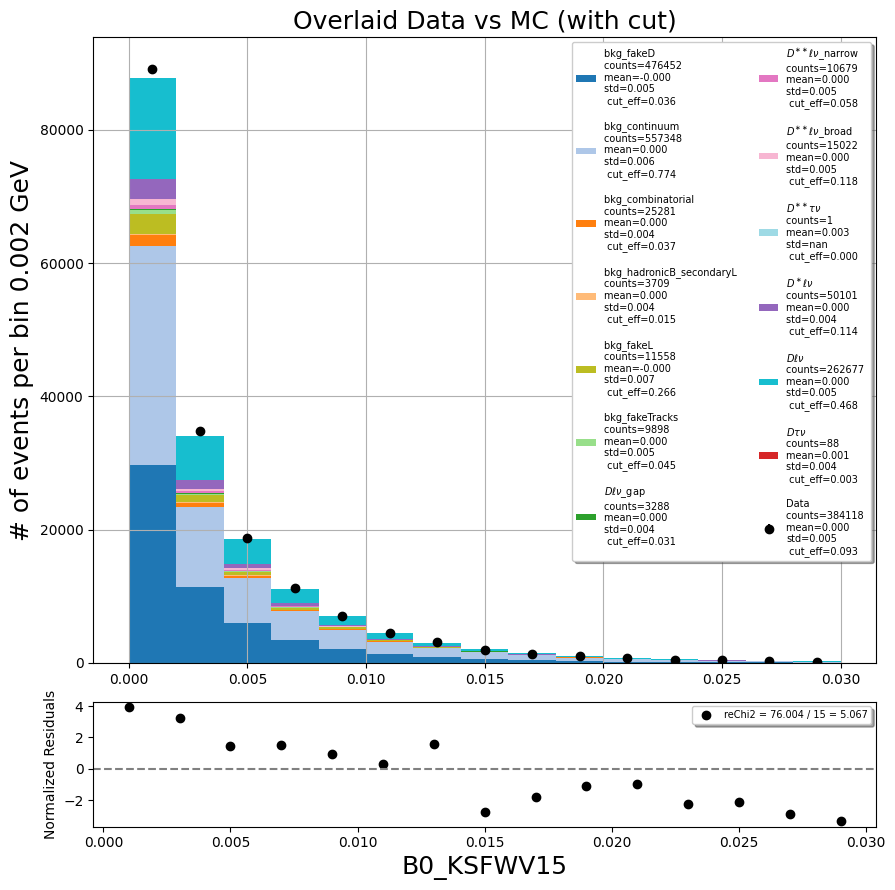

In [73]:
b1 = np.linspace(0,0.03,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV15',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


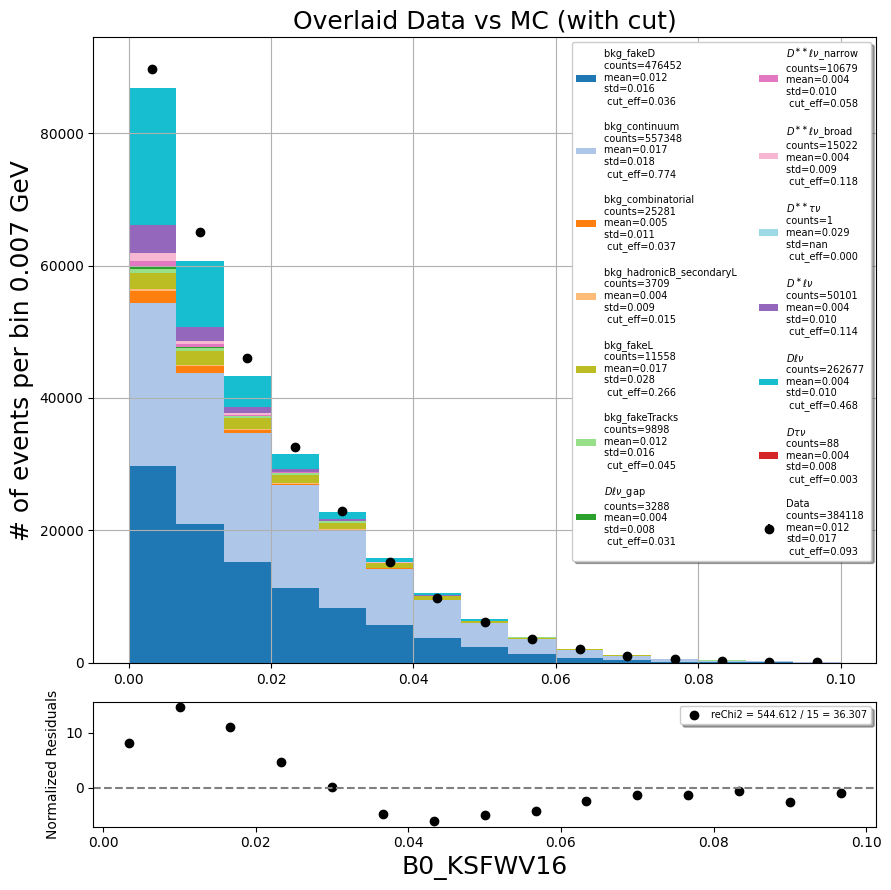

In [75]:
b1 = np.linspace(0,0.1,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV16',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


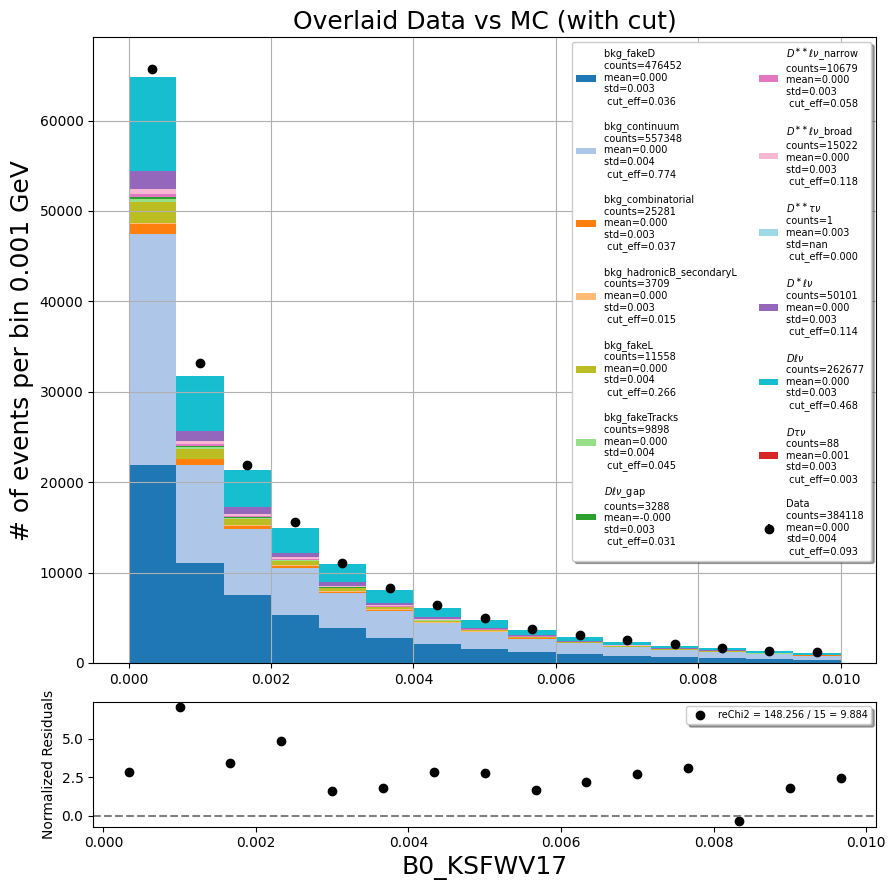

In [78]:
b1 = np.linspace(0,0.01,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV17',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885


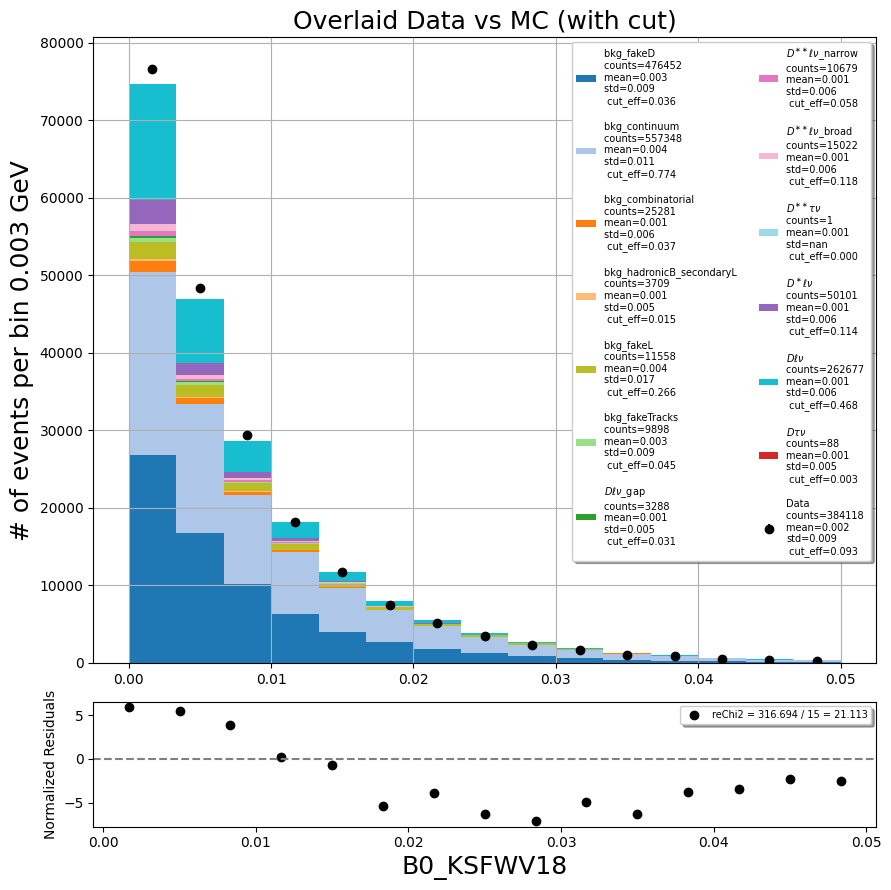

In [80]:
b1 = np.linspace(0,0.05,16)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl_all.plot_data_mc_stacked(
    variable='B0_KSFWV18',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')